# 03: Feature Engineering

## Objective
Create temporal, lag, and external features for time series forecasting models.

## Tasks
- Create temporal features (day of week, month, holidays)
- Generate lag features (previous days)
- Create rolling statistics
- Optional: Add external features (weather, flu data)


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import holidays
import os

# Setup paths - mount Google Drive if not already mounted (matching notebook 02)
DRIVE_MOUNTED = False
DRIVE_DATA_PROCESSED = None

try:
    from google.colab import drive
    # Check if drive is already mounted
    if os.path.exists('/content/drive'):
        DRIVE_MOUNTED = True
        print("✓ Google Drive already mounted")
    else:
        # Mount Google Drive
        print("📁 Mounting Google Drive...")
        drive.mount('/content/drive')
        DRIVE_MOUNTED = True
        print("✓ Google Drive mounted successfully")

    # Set up Google Drive paths
    if DRIVE_MOUNTED:
        DRIVE_ROOT = '/content/drive/MyDrive/hospital_admissions_forecasting'
        DRIVE_DATA_PROCESSED = os.path.join(DRIVE_ROOT, 'data', 'processed')
        os.makedirs(DRIVE_DATA_PROCESSED, exist_ok=True)
        print(f"✓ Google Drive paths configured: {DRIVE_ROOT}")
except ImportError:
    print("ℹ️  Not running in Google Colab (will only check local paths)")
except Exception as e:
    print(f"⚠️  Could not mount Google Drive: {e}")
    print("   Will continue with local Colab paths only")

# Local Colab paths
PROJECT_ROOT = '/content/hospital_admissions_forecasting'
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
DATA_RAW = os.path.join(DATA_DIR, 'raw')
DATA_PROCESSED = os.path.join(DATA_DIR, 'processed')

for path in [DATA_RAW, DATA_PROCESSED]:
    os.makedirs(path, exist_ok=True)



📁 Mounting Google Drive...
Mounted at /content/drive
✓ Google Drive mounted successfully
✓ Google Drive paths configured: /content/drive/MyDrive/hospital_admissions_forecasting


## Load Daily Time Series Data


In [2]:
# Load daily admissions time series from previous notebook
# Try loading from multiple locations (priority: local > drive, matching notebook 02)
file_paths = [
    (DATA_PROCESSED, 'daily_admissions.csv'),
    (DRIVE_DATA_PROCESSED, 'daily_admissions.csv') if DRIVE_DATA_PROCESSED else None
]

daily_admissions = pd.DataFrame()
for path_info in file_paths:
    if path_info is None:
        continue
    folder, filename = path_info
    file_path = os.path.join(folder, filename)
    if os.path.exists(file_path):
        try:
            daily_admissions = pd.read_csv(file_path, index_col=0, parse_dates=True)
            print(f"✓ Loaded {len(daily_admissions):,} days from {file_path}")
            print(f"Date range: {daily_admissions.index.min()} to {daily_admissions.index.max()}")
            print(f"  (Note: MIMIC-IV dates are shifted ~100 years for privacy)")

            # ============================================================
            # DATA FILTERING: OPTIMAL TRAINING PERIOD
            # ============================================================
            # Based on exploratory analysis, filter to optimal training period (2120-2185)
            # This excludes low-activity periods with data quality concerns
            # The peak/plateau phase (2120-2185) is the most stable, high-activity period
            FILTER_TO_OPTIMAL_PERIOD = False  # Set to False to use all data

            if FILTER_TO_OPTIMAL_PERIOD:
                optimal_start = pd.Timestamp('2120-01-01')
                optimal_end = pd.Timestamp('2185-12-31')
                original_len = len(daily_admissions)
                daily_admissions = daily_admissions[
                    (daily_admissions.index >= optimal_start) &
                    (daily_admissions.index <= optimal_end)
                ]
                filtered_len = len(daily_admissions)
                print(f"\n📊 Data Filtering (Optimal Training Period):")
                print(f"  Original data: {original_len:,} days")
                print(f"  Filtered to optimal period (2120-2185): {filtered_len:,} days")
                print(f"  Removed: {original_len - filtered_len:,} days ({100*(original_len-filtered_len)/original_len:.1f}%)")
                print(f"  New date range: {daily_admissions.index.min()} to {daily_admissions.index.max()}")
            else:
                print(f"\n📊 Using all data (no filtering applied)")

            print(f"\nFirst few rows:")
            print(daily_admissions.head())
            break
        except Exception as e:
            print(f"⚠️  Error loading {file_path}: {e}")

if len(daily_admissions) == 0:
    print("❌ Data file not found. Please run notebook 02_exploratory_analysis.ipynb first.")
    print(f"   Checked locations:")
    for path_info in file_paths:
        if path_info:
            print(f"     - {os.path.join(path_info[0], path_info[1])}")


✓ Loaded 39,884 days from /content/drive/MyDrive/hospital_admissions_forecasting/data/processed/daily_admissions.csv
Date range: 2105-10-04 00:00:00 to 2214-12-15 00:00:00
  (Note: MIMIC-IV dates are shifted ~100 years for privacy)

📊 Using all data (no filtering applied)

First few rows:
            admissions
2105-10-04           1
2105-10-05           0
2105-10-06           0
2105-10-07           0
2105-10-08           0


## Create Temporal Features


In [3]:
# Create temporal features
if len(daily_admissions) > 0:
    features_df = daily_admissions.copy()
    features_df['day_of_week'] = features_df.index.dayofweek
    features_df['day_of_week_name'] = features_df.index.day_name()
    features_df['month'] = features_df.index.month
    features_df['month_name'] = features_df.index.month_name()
    features_df['day_of_month'] = features_df.index.day
    features_df['week_of_year'] = features_df.index.isocalendar().week
    features_df['quarter'] = features_df.index.quarter
    features_df['year'] = features_df.index.year
    features_df['is_weekend'] = (features_df['day_of_week'] >= 5).astype(int)
    features_df['is_month_start'] = features_df.index.is_month_start.astype(int)
    features_df['is_month_end'] = features_df.index.is_month_end.astype(int)

    # Additional temporal features
    features_df['day_of_year'] = features_df.index.dayofyear  # 1-365/366 for annual seasonality
    features_df['week_of_month'] = ((features_df.index.day - 1) // 7) + 1  # Week within month (1-5)
    features_df['is_quarter_start'] = features_df.index.is_quarter_start.astype(int)
    features_df['is_quarter_end'] = features_df.index.is_quarter_end.astype(int)

    # ============================================================
    # CYCLICAL ENCODING (UPDATED BASED ON EDA)
    # ============================================================
    # REMOVED: day_of_week_sin/cos (day-of-week effect too weak: 0.25 admissions range, 0.7% CV)
    # REMOVED: month_sin/cos (monthly effect too weak: 0.19 admissions range, 0.5% CV)
    # KEPT: day_of_year_sin/cos (annual seasonality is important)
    # ADDED: quarter_sin/cos (quarterly seasonality)

    # Day of year (1-365/366) -> sin/cos with period 365.25 (accounting for leap years)
    # This captures annual seasonality which is more important than weekly/monthly
    max_day_of_year = 366  # Account for leap years
    features_df['day_of_year_sin'] = np.sin(2 * np.pi * features_df['day_of_year'] / max_day_of_year)
    features_df['day_of_year_cos'] = np.cos(2 * np.pi * features_df['day_of_year'] / max_day_of_year)

    # Quarterly cyclical encoding (alternative to monthly - more meaningful)
    features_df['quarter_sin'] = np.sin(2 * np.pi * features_df['quarter'] / 4)
    features_df['quarter_cos'] = np.cos(2 * np.pi * features_df['quarter'] / 4)

    # ============================================================
    # ADDITIONAL INTERACTION FEATURES
    # ============================================================
    # Interaction features capture combined effects of multiple variables
    print("\nCreating interaction features...")

    # REMOVED: Day-of-week interactions (day-of-week effect too weak)
    # REMOVED: Monthly interactions (monthly effect too weak)
    # KEPT: Quarterly and weekend interactions (more meaningful)

    # Weekend × Quarter (weekend patterns may vary by season/quarter)
    features_df['weekend_quarter_interaction'] = features_df['is_weekend'] * features_df['quarter']

    # Quarter × Day of year (captures seasonal patterns within quarters)
    features_df['quarter_doy_interaction'] = features_df['quarter'] * (features_df['day_of_year'] / 91.25)  # Normalized

    print("  ✓ Interaction features created:")
    print(f"    - weekend_quarter_interaction")
    print(f"    - quarter_doy_interaction")
    print("\n  Note: Removed day-of-week and monthly interactions (effects too weak per EDA)")

    print("\nTemporal features created (updated based on EDA):")
    print("  - Removed: day_of_week, month cyclical features (effects too weak)")
    print("  - Kept: quarter, is_weekend, day_of_year (more meaningful)")
    print(features_df[['admissions', 'quarter', 'is_weekend', 'day_of_year']].head(10))



Creating interaction features...
  ✓ Interaction features created:
    - weekend_quarter_interaction
    - quarter_doy_interaction

  Note: Removed day-of-week and monthly interactions (effects too weak per EDA)

Temporal features created (updated based on EDA):
  - Removed: day_of_week, month cyclical features (effects too weak)
  - Kept: quarter, is_weekend, day_of_year (more meaningful)
            admissions  quarter  is_weekend  day_of_year
2105-10-04           1        4           1          277
2105-10-05           0        4           0          278
2105-10-06           0        4           0          279
2105-10-07           0        4           0          280
2105-10-08           0        4           0          281
2105-10-09           0        4           0          282
2105-10-10           0        4           1          283
2105-10-11           0        4           1          284
2105-10-12           0        4           0          285
2105-10-13           0        4     

## Create Holiday Features


In [4]:
# Add US federal holidays
# Note: MIMIC-IV dates are shifted ~100 years (2105-2214), but holidays library works for any year
# We'll adjust dates by subtracting ~100 years to check holidays, preserving variable holidays (e.g., Thanksgiving)
if len(features_df) > 0:
    # Calculate the date shift (approximately 100 years)
    date_shift_years = features_df.index.min().year - 2000  # Shift to year 2000 range

    # Get holidays for the adjusted year range
    adjusted_min_year = features_df.index.min().year - date_shift_years
    adjusted_max_year = features_df.index.max().year - date_shift_years
    us_holidays = holidays.UnitedStates(years=range(adjusted_min_year, adjusted_max_year + 1))

    # Check if each date (adjusted by subtracting date_shift_years) is a holiday
    # Use pd.DateOffset to properly handle leap years and month boundaries
    features_df['is_holiday'] = features_df.index.to_series().apply(
        lambda x: (x - pd.DateOffset(years=date_shift_years)).date() in us_holidays
    ).astype(int)

    # For holidays_in_week, check nearby dates
    features_df['holidays_in_week'] = features_df.index.to_series().apply(
        lambda x: sum([(x + pd.Timedelta(days=i) - pd.DateOffset(years=date_shift_years)).date() in us_holidays
                      for i in range(-3, 4)])
    )

    # Interaction features: weekend * holiday (captures holiday weekends)
    features_df['is_holiday_weekend'] = (features_df['is_holiday'] * features_df['is_weekend']).astype(int)

    print(f"Holiday features created | Total holidays: {features_df['is_holiday'].sum()}")
    print(f"  Holiday weekends: {features_df['is_holiday_weekend'].sum()}")
    if features_df['is_holiday'].sum() > 0:
        print(features_df[features_df['is_holiday'] == 1][['admissions', 'is_holiday', 'is_weekend']].head())
    else:
        print("  (Note: Dates adjusted by ~100 years for holiday detection)")


Holiday features created | Total holidays: 1224
  Holiday weekends: 270
            admissions  is_holiday  is_weekend
2105-10-09           0           1           0
2105-11-10           0           1           0
2105-11-11           0           1           0
2105-11-23           0           1           0
2105-12-25           0           1           0


## Create Lag Features


In [5]:
# Create lagged features (previous days)
# UPDATED: Simplified to keep only most important lags (1, 7, 365)
# Removed redundant lags (2, 3, 14, 30) - these are less interpretable and may be redundant
# Note: NaN values at start are EXPECTED - first N rows have no previous data to reference
# These NaN rows will be removed in the cleaning step below
if len(features_df) > 0:
    # Most important lags:
    # - Lag 1: Yesterday's admissions (most direct effect on today)
    # - Lag 7: Same day last week (weekly patterns)
    # - Lag 365: Same day last year (annual seasonality)
    features_df['admissions_lag_1'] = features_df['admissions'].shift(1)
    features_df['admissions_lag_7'] = features_df['admissions'].shift(7)

    # Year-over-year lag (365 days) - captures annual seasonality
    # Important for hospital admissions which often have strong annual patterns
    if len(features_df) >= 365:
        features_df['admissions_lag_365'] = features_df['admissions'].shift(365)

    print("Lag features created (simplified - keeping only lags 1, 7, 365):")
    print("  - Removed redundant lags (2, 3, 14, 30) per logical analysis")
    lag_cols = ['admissions', 'admissions_lag_1', 'admissions_lag_7']
    if 'admissions_lag_365' in features_df.columns:
        lag_cols.append('admissions_lag_365')
    print(features_df[lag_cols].head(10))


Lag features created (simplified - keeping only lags 1, 7, 365):
  - Removed redundant lags (2, 3, 14, 30) per logical analysis
            admissions  admissions_lag_1  admissions_lag_7  admissions_lag_365
2105-10-04           1               NaN               NaN                 NaN
2105-10-05           0               1.0               NaN                 NaN
2105-10-06           0               0.0               NaN                 NaN
2105-10-07           0               0.0               NaN                 NaN
2105-10-08           0               0.0               NaN                 NaN
2105-10-09           0               0.0               NaN                 NaN
2105-10-10           0               0.0               NaN                 NaN
2105-10-11           0               0.0               1.0                 NaN
2105-10-12           0               0.0               0.0                 NaN
2105-10-13           0               0.0               0.0                 NaN


## Create Rolling Statistics


In [6]:
# Create rolling window statistics
# Note: NaN values at start are EXPECTED until the rolling window is filled
# Example: rolling_mean_7 has NaN for first 6 days (need 7 days to calculate mean)
if len(features_df) > 0:
    # 7-day rolling statistics
    features_df['rolling_mean_7'] = features_df['admissions'].rolling(window=7, center=False).mean()
    features_df['rolling_std_7'] = features_df['admissions'].rolling(window=7, center=False).std()
    features_df['rolling_min_7'] = features_df['admissions'].rolling(window=7, center=False).min()
    features_df['rolling_max_7'] = features_df['admissions'].rolling(window=7, center=False).max()
    features_df['rolling_median_7'] = features_df['admissions'].rolling(window=7, center=False).median()

    # 30-day rolling statistics
    features_df['rolling_mean_30'] = features_df['admissions'].rolling(window=30, center=False).mean()
    features_df['rolling_std_30'] = features_df['admissions'].rolling(window=30, center=False).std()
    features_df['rolling_median_30'] = features_df['admissions'].rolling(window=30, center=False).median()

    # 365-day rolling statistics (annual trend)
    if len(features_df) > 365:
        features_df['rolling_mean_365'] = features_df['admissions'].rolling(window=365, center=False).mean()
        features_df['rolling_median_365'] = features_df['admissions'].rolling(window=365, center=False).median()

    print("Rolling statistics created (NaN at start is expected - will be removed later):")
    print(features_df[['admissions', 'rolling_mean_7', 'rolling_median_7', 'rolling_mean_30']].head(10))


Rolling statistics created (NaN at start is expected - will be removed later):
            admissions  rolling_mean_7  rolling_median_7  rolling_mean_30
2105-10-04           1             NaN               NaN              NaN
2105-10-05           0             NaN               NaN              NaN
2105-10-06           0             NaN               NaN              NaN
2105-10-07           0             NaN               NaN              NaN
2105-10-08           0             NaN               NaN              NaN
2105-10-09           0             NaN               NaN              NaN
2105-10-10           0        0.142857               0.0              NaN
2105-10-11           0        0.000000               0.0              NaN
2105-10-12           0        0.000000               0.0              NaN
2105-10-13           0        0.000000               0.0              NaN


## Create Change Features


In [7]:
# Create change features (day-over-day, week-over-week)
# These capture momentum and short-term trends
if len(features_df) > 0:
    # Day-over-day change (absolute and percentage)
    features_df['admissions_change_1'] = features_df['admissions'].diff(1)  # Day-over-day change
    features_df['admissions_pct_change_1'] = features_df['admissions'].pct_change(1)  # Percentage change

    # Week-over-week change (7 days)
    features_df['admissions_change_7'] = features_df['admissions'].diff(7)  # Week-over-week change
    features_df['admissions_pct_change_7'] = features_df['admissions'].pct_change(7)  # Percentage change

    # Month-over-month change (30 days)
    if len(features_df) > 30:
        features_df['admissions_change_30'] = features_df['admissions'].diff(30)
        features_df['admissions_pct_change_30'] = features_df['admissions'].pct_change(30)

    # Fill NaN values from change calculations with 0 (no change on first days)
    change_cols = [col for col in features_df.columns if 'change' in col]
    for col in change_cols:
        features_df[col] = features_df[col].fillna(0)

    print("Change features created:")
    print(features_df[['admissions', 'admissions_change_1', 'admissions_change_7', 'admissions_pct_change_7']].head(10))

    # ============================================================
    # TIME-BASED FEATURES (Days Since/Until Events)
    # ============================================================
    # These capture temporal proximity to important events
    print("\nCreating time-based features (days since/until events)...")

    # Days since last holiday
    features_df['days_since_holiday'] = 0
    last_holiday_idx = None
    for idx in features_df.index:
        if features_df.loc[idx, 'is_holiday'] == 1:
            last_holiday_idx = idx
            features_df.loc[idx, 'days_since_holiday'] = 0
        elif last_holiday_idx is not None:
            days_since = (idx - last_holiday_idx).days
            features_df.loc[idx, 'days_since_holiday'] = days_since
        else:
            features_df.loc[idx, 'days_since_holiday'] = 999  # No holiday yet

    # REMOVED: days_until_next_holiday (DATA LEAKAGE - uses future information)
    # REMOVED: days_since_weekend, days_until_weekend (redundant with day_of_week and is_weekend)
    # REMOVED: days_since_month_start, days_until_month_end (redundant with day_of_month)
    # KEPT: days_since_holiday (captures post-holiday effects, no leakage)

    print("  ✓ Time-based features created:")
    print(f"    - days_since_holiday (post-holiday effects)")
    print(f"    - Removed: days_until_next_holiday (data leakage), days_since/until_weekend/month (redundant)")

    # ============================================================
    # ZERO-INFLATION FEATURES
    # ============================================================
    # Based on EDA: Distribution shows strong zero-inflation (>3500 days with 0 admissions)
    # These features explicitly model zero patterns to help models distinguish between:
    # - Days with zero admissions (predictable patterns)
    # - Days with normal admissions (13-18 range)
    # - Days with extreme admissions (35-40 outliers)
    # NOTE: If using filtered period (2120-2185), zeros may not exist - features will be skipped
    print("\nCreating zero-inflation features (to handle zero-inflated distribution)...")

    # Check if zeros exist in the data (if filtered period has no zeros, skip these features)
    zeros_exist = (features_df['admissions'] == 0).sum() > 0
    if not zeros_exist:
        print("  ⚠️  No zeros found in data - skipping zero-inflation features")
        print("     (If using filtered period, zeros may have been removed)")
        print("     Zero-inflation features will not be created.")

    # Only create zero-inflation features if zeros exist in the data
    if zeros_exist:
        # 1. Zero indicators (was there a zero recently?)
        if 'admissions_lag_1' in features_df.columns:
            features_df['was_zero_yesterday'] = (features_df['admissions_lag_1'] == 0).astype(int)
        if 'admissions_lag_7' in features_df.columns:
            features_df['was_zero_last_week'] = (features_df['admissions_lag_7'] == 0).astype(int)
        if 'admissions_lag_365' in features_df.columns:
            features_df['was_zero_last_year'] = (features_df['admissions_lag_365'] == 0).astype(int)
    else:
        # Create empty placeholders (will be removed as constant features)
        if 'admissions_lag_1' in features_df.columns:
            features_df['was_zero_yesterday'] = 0
        if 'admissions_lag_7' in features_df.columns:
            features_df['was_zero_last_week'] = 0
        if 'admissions_lag_365' in features_df.columns:
            features_df['was_zero_last_year'] = 0

    # 2. Consecutive zeros (how many days in a row with zero admissions?)
    # FIXED: Use lagged admissions to avoid data leakage
    # We calculate consecutive zeros based on yesterday's value, then shift forward
    if zeros_exist:
        features_df['consecutive_zeros'] = 0
        zero_count = 0
        for idx in features_df.index:
            # Use lag_1 to avoid data leakage (yesterday's admissions)
            if 'admissions_lag_1' in features_df.columns:
                lag_val = features_df.loc[idx, 'admissions_lag_1']
                if pd.notna(lag_val) and lag_val == 0:
                    zero_count += 1
                else:
                    zero_count = 0
            else:
                # If no lag_1, can't calculate (shouldn't happen)
                zero_count = 0
            features_df.loc[idx, 'consecutive_zeros'] = zero_count
    else:
        features_df['consecutive_zeros'] = 0

    # 3. Zero probability in rolling windows (proportion of zeros in recent period)
    # FIXED: Use lagged admissions to avoid data leakage
    # Calculate zero probability based on lagged values (excluding current day)
    if zeros_exist and 'admissions_lag_1' in features_df.columns:
        # Use lag_1 for rolling calculations (excludes current day)
        # Apply lambda function to count zeros within each rolling window
        features_df['prob_zero_7'] = features_df['admissions_lag_1'].rolling(window=7).apply(
            lambda x: (x == 0).sum() / len(x) if len(x) > 0 else 0, raw=True
        )
        features_df['prob_zero_30'] = features_df['admissions_lag_1'].rolling(window=30).apply(
            lambda x: (x == 0).sum() / len(x) if len(x) > 0 else 0, raw=True
        )
        if len(features_df) > 365:
            features_df['prob_zero_365'] = features_df['admissions_lag_1'].rolling(window=365).apply(
                lambda x: (x == 0).sum() / len(x) if len(x) > 0 else 0, raw=True
            )
    else:
        # No zeros in data - set to 0
        features_df['prob_zero_7'] = 0
        features_df['prob_zero_30'] = 0
        if len(features_df) > 365:
            features_df['prob_zero_365'] = 0

        # 4. Days since last non-zero admission
    # FIXED: Calculate based on lagged admissions, then shift forward to avoid data leakage
    # This captures how long it's been since the hospital had any admissions (based on yesterday's data)
    if zeros_exist:
        # We'll calculate for lagged values, then shift forward
        temp_days_since_nonzero = pd.Series(index=features_df.index, dtype=float)
        last_nonzero_idx = None
        for idx in features_df.index:
            # Use lag_1 to avoid data leakage
            if 'admissions_lag_1' in features_df.columns:
                lag_val = features_df.loc[idx, 'admissions_lag_1']
                if pd.notna(lag_val) and lag_val > 0:
                    last_nonzero_idx = idx
                    temp_days_since_nonzero.loc[idx] = 0
                elif last_nonzero_idx is not None:
                    days_since = (idx - last_nonzero_idx).days
                    temp_days_since_nonzero.loc[idx] = days_since
                else:
                    temp_days_since_nonzero.loc[idx] = 999  # No non-zero yet (at start of data)
            else:
                temp_days_since_nonzero.loc[idx] = 999

        # Shift forward by 1 day (yesterday's "days since nonzero" becomes today's feature)
        features_df['days_since_nonzero'] = temp_days_since_nonzero.shift(1).fillna(999)
    else:
        # No zeros - set to 0 (always have non-zero admissions)
        features_df['days_since_nonzero'] = 0

    # 5. Count of zeros in rolling windows
    # FIXED: Use lagged admissions to avoid data leakage
    if zeros_exist and 'admissions_lag_1' in features_df.columns:
        features_df['zeros_count_7'] = features_df['admissions_lag_1'].rolling(window=7).apply(
            lambda x: (x == 0).sum(), raw=True
        )
        features_df['zeros_count_30'] = features_df['admissions_lag_1'].rolling(window=30).apply(
            lambda x: (x == 0).sum(), raw=True
        )
    else:
        # No zeros - set to 0
        features_df['zeros_count_7'] = 0
        features_df['zeros_count_30'] = 0

        # 6. Extreme value indicators (for right tail - outliers at 35-40 admissions)
    # Based on EDA: Several days with 35-40 admissions (unusually high)
    # Define extreme as > 30 (approximately 95th percentile based on distribution)
    # NOTE: These features are useful even without zeros (capture extreme high values)
    if 'admissions_lag_1' in features_df.columns:
        features_df['was_extreme_high_yesterday'] = (features_df['admissions_lag_1'] > 30).astype(int)
    else:
        features_df['was_extreme_high_yesterday'] = 0

    if 'admissions_lag_7' in features_df.columns:
        features_df['was_extreme_high_last_week'] = (features_df['admissions_lag_7'] > 30).astype(int)
    else:
        features_df['was_extreme_high_last_week'] = 0

    # Days since extreme high admission (recovery period)
    # FIXED: Calculate based on lagged admissions to avoid data leakage
    # Check if extreme values exist
    extreme_values_exist = False
    if 'admissions_lag_1' in features_df.columns:
        extreme_values_exist = (features_df['admissions_lag_1'] > 30).sum() > 0

    if extreme_values_exist:
        temp_days_since_extreme = pd.Series(index=features_df.index, dtype=float)
        last_extreme_idx = None
        for idx in features_df.index:
            # Use lag_1 to avoid data leakage
            if 'admissions_lag_1' in features_df.columns:
                lag_val = features_df.loc[idx, 'admissions_lag_1']
                if pd.notna(lag_val) and lag_val > 30:
                    last_extreme_idx = idx
                    temp_days_since_extreme.loc[idx] = 0
                elif last_extreme_idx is not None:
                    days_since = (idx - last_extreme_idx).days
                    temp_days_since_extreme.loc[idx] = days_since
                else:
                    temp_days_since_extreme.loc[idx] = 999  # No extreme high yet
            else:
                temp_days_since_extreme.loc[idx] = 999

        # Shift forward by 1 day (yesterday's "days since extreme" becomes today's feature)
        features_df['days_since_extreme_high'] = temp_days_since_extreme.shift(1).fillna(999)
    else:
        # No extreme values - set to 999 (never had extreme high)
        features_df['days_since_extreme_high'] = 999

    # Fill NaN values from zero-inflation features
    zero_inflation_cols = [
        'was_zero_yesterday', 'was_zero_last_week', 'was_zero_last_year',
        'consecutive_zeros', 'prob_zero_7', 'prob_zero_30', 'prob_zero_365',
        'days_since_nonzero', 'zeros_count_7', 'zeros_count_30',
        'was_extreme_high_yesterday', 'was_extreme_high_last_week', 'days_since_extreme_high'
    ]
    for col in zero_inflation_cols:
        if col in features_df.columns:
            features_df[col] = features_df[col].fillna(0)

    # Print summary
    zero_inflation_cols = [
        'was_zero_yesterday', 'was_zero_last_week', 'was_zero_last_year',
        'consecutive_zeros', 'prob_zero_7', 'prob_zero_30', 'prob_zero_365',
        'days_since_nonzero', 'zeros_count_7', 'zeros_count_30',
        'was_extreme_high_yesterday', 'was_extreme_high_last_week', 'days_since_extreme_high'
    ]
    created_cols = [col for col in zero_inflation_cols if col in features_df.columns]

    if zeros_exist:
        print("  ✓ Zero-inflation features created:")
        print(f"    - Zero indicators: was_zero_yesterday, was_zero_last_week, was_zero_last_year")
        print(f"    - Consecutive zeros: consecutive_zeros")
        print(f"    - Zero probability: prob_zero_7, prob_zero_30, prob_zero_365")
        print(f"    - Days since non-zero: days_since_nonzero")
        print(f"    - Zero counts: zeros_count_7, zeros_count_30")
        print(f"    - Extreme value indicators: was_extreme_high_yesterday, was_extreme_high_last_week, days_since_extreme_high")
        print(f"    - Total zero-inflation features: {len(created_cols)}")
    else:
        print("  ⚠️  Zero-inflation features created but will be constant (no zeros in data):")
        print(f"    - Created {len(created_cols)} features (will be removed as constant)")
        print(f"    - Extreme value features may still be useful (was_extreme_high_*)")
        print(f"    - If using filtered period, zeros may have been removed")


Change features created:
            admissions  admissions_change_1  admissions_change_7  \
2105-10-04           1                  0.0                  0.0   
2105-10-05           0                 -1.0                  0.0   
2105-10-06           0                  0.0                  0.0   
2105-10-07           0                  0.0                  0.0   
2105-10-08           0                  0.0                  0.0   
2105-10-09           0                  0.0                  0.0   
2105-10-10           0                  0.0                  0.0   
2105-10-11           0                  0.0                 -1.0   
2105-10-12           0                  0.0                  0.0   
2105-10-13           0                  0.0                  0.0   

            admissions_pct_change_7  
2105-10-04                      0.0  
2105-10-05                      0.0  
2105-10-06                      0.0  
2105-10-07                      0.0  
2105-10-08                      0.0 

## Add KPI Features (if available)


In [8]:
# Add KPI features if available
# Try loading from multiple locations (matching notebook 02)
kpi_file_paths = [
    (DATA_PROCESSED, 'daily_kpis.csv'),
    (DRIVE_DATA_PROCESSED, 'daily_kpis.csv') if DRIVE_DATA_PROCESSED else None
]

kpi_data = None
for path_info in kpi_file_paths:
    if path_info is None:
        continue
    folder, filename = path_info
    kpi_file = os.path.join(folder, filename)
    if os.path.exists(kpi_file):
        try:
            kpi_data = pd.read_csv(kpi_file, index_col=0, parse_dates=True)
            print(f"✓ Loaded KPI data from {kpi_file}")
            break
        except Exception as e:
            print(f"⚠️  Error loading {kpi_file}: {e}")

if kpi_data is not None and len(kpi_data) > 0:
    # Align KPI data with features_df index
    kpi_data = kpi_data.reindex(features_df.index)

    # ============================================================
    # CAPACITY CONSTRAINT FEATURES
    # ============================================================
    # These features model when hospital is at or near capacity,
    # which can constrain admissions or affect admission patterns

    # Check for bed occupancy column (may have different names)
    bed_occ_col = None
    if 'bed_occupancy_rate' in kpi_data.columns:
        bed_occ_col = 'bed_occupancy_rate'
    elif 'bed_occupancy' in kpi_data.columns:
        bed_occ_col = 'bed_occupancy'
    elif 'occupancy_rate' in kpi_data.columns:
        bed_occ_col = 'occupancy_rate'

    if bed_occ_col is not None:
        print("\n  Creating capacity constraint features from bed occupancy data...")

        # 1. Direct capacity indicators
        # FIXED: Use lagged bed_occupancy_rate to avoid data leakage
        # Current day's bed_occupancy may include same-day admissions (leakage)
        # Yesterday's capacity affects today's admissions (causal and no leakage)
        bed_occupancy_series = kpi_data[bed_occ_col]
        features_df['bed_occupancy_lag_1'] = bed_occupancy_series.shift(1)

        # Also keep current for reference, but models should use lag_1
        features_df['bed_occupancy_rate'] = bed_occupancy_series

        # 2. Capacity threshold indicators (industry standard thresholds)
        # Use lagged occupancy for thresholds to avoid leakage
        # Near capacity: 85% (common threshold for operational alerts)
        features_df['near_capacity'] = (features_df['bed_occupancy_lag_1'] >= 0.85).astype(int)

        # At capacity: 95% (critical threshold - may start diverting patients)
        features_df['at_capacity'] = (features_df['bed_occupancy_lag_1'] >= 0.95).astype(int)

        # Over capacity: >100% (overflow situations - rare but critical)
        features_df['over_capacity'] = (features_df['bed_occupancy_lag_1'] > 1.0).astype(int)

        # 3. Capacity zones (categorical encoding)
        # Low: <70%, Medium: 70-85%, High: 85-95%, Critical: >95%
        # Use lagged occupancy to avoid leakage
        def capacity_zone(rate):
            if pd.isna(rate):
                return 0
            elif rate < 0.70:
                return 1  # Low
            elif rate < 0.85:
                return 2  # Medium
            elif rate < 0.95:
                return 3  # High
            else:
                return 4  # Critical

        features_df['capacity_zone'] = features_df['bed_occupancy_lag_1'].apply(capacity_zone)

        # 4. Distance from capacity thresholds (using lagged occupancy)
        features_df['distance_from_85pct'] = features_df['bed_occupancy_lag_1'] - 0.85
        features_df['distance_from_95pct'] = features_df['bed_occupancy_lag_1'] - 0.95

        # 5. Additional lagged capacity features
        # bed_occupancy_lag_1 already created above (primary feature)
        features_df['bed_occupancy_lag_7'] = bed_occupancy_series.shift(7)
        features_df['near_capacity_lag_1'] = features_df['near_capacity']  # Already based on lag_1
        features_df['at_capacity_lag_1'] = features_df['at_capacity']  # Already based on lag_1

        # 6. Rolling capacity statistics (trend in capacity)
        # Use lagged occupancy for rolling stats to avoid leakage
        features_df['capacity_rolling_mean_7'] = features_df['bed_occupancy_lag_1'].rolling(window=7).mean()
        features_df['capacity_rolling_mean_30'] = features_df['bed_occupancy_lag_1'].rolling(window=30).mean()
        # Removed: capacity_rolling_max_7 (less informative than mean)

        # 7. Capacity change features (is capacity increasing/decreasing?)
        # Use lagged occupancy for changes
        features_df['capacity_change_1'] = features_df['bed_occupancy_lag_1'].diff(1)
        features_df['capacity_change_7'] = features_df['bed_occupancy_lag_1'].diff(7)
        # Removed: capacity_pct_change_7 (may be redundant with capacity_change_7)

        # 8. Interaction features: capacity × weekend
        # Capacity constraints may affect weekends differently
        # Use lagged occupancy for interactions
        features_df['near_capacity_weekend'] = (features_df['near_capacity'] * features_df['is_weekend']).astype(int)
        # Removed: capacity_weekend (multiplication may not add value beyond base features)

        # 9. Days at high capacity (consecutive days near/at capacity)
        # This captures sustained capacity pressure
        # FIXED: Added data validation and cap to prevent unrealistic values
        features_df['days_near_capacity'] = 0
        features_df['days_at_capacity'] = 0

        # Check if bed occupancy data is valid (not constant/unrealistic)
        occupancy_valid = True
        if features_df['bed_occupancy_rate'].nunique() < 10:
            print("  ⚠️  Warning: Bed occupancy has very few unique values - data may be constant/aggregated")
            occupancy_valid = False

        # Check for unrealistic constant high occupancy
        high_occupancy_pct = (features_df['bed_occupancy_rate'] >= 0.85).sum() / len(features_df)
        if high_occupancy_pct > 0.95:
            print(f"  ⚠️  Warning: {high_occupancy_pct*100:.1f}% of days are near capacity - data may be unrealistic")
            occupancy_valid = False

        near_capacity_count = 0
        at_capacity_count = 0
        max_reasonable_days = 365  # Cap at 1 year (reasonable maximum)

        # Use lagged capacity indicators for consecutive days calculation
        for idx in features_df.index:
            # Use lagged near_capacity (already based on lag_1)
            if pd.notna(features_df.loc[idx, 'near_capacity']) and features_df.loc[idx, 'near_capacity'] == 1:
                near_capacity_count += 1
            else:
                near_capacity_count = 0
            # Cap at reasonable maximum to prevent unrealistic values
            features_df.loc[idx, 'days_near_capacity'] = min(near_capacity_count, max_reasonable_days)

            # Use lagged at_capacity (already based on lag_1)
            if pd.notna(features_df.loc[idx, 'at_capacity']) and features_df.loc[idx, 'at_capacity'] == 1:
                at_capacity_count += 1
            else:
                at_capacity_count = 0
            # Cap at reasonable maximum
            features_df.loc[idx, 'days_at_capacity'] = min(at_capacity_count, max_reasonable_days)

        # Report if values were capped
        if features_df['days_near_capacity'].max() >= max_reasonable_days:
            print(f"  ⚠️  Note: days_near_capacity capped at {max_reasonable_days} days (some values exceeded this)")

        print(f"  ✓ Capacity constraint features created:")
        print(f"    - Capacity indicators: near_capacity, at_capacity, over_capacity")
        print(f"    - Capacity zones: {features_df['capacity_zone'].value_counts().to_dict()}")
        print(f"    - Days near capacity (max): {features_df['days_near_capacity'].max()}")
        print(f"    - Days at capacity (max): {features_df['days_at_capacity'].max()}")
        print(f"    - Capacity statistics:")
        print(f"      Mean occupancy: {features_df['bed_occupancy_rate'].mean():.2%}")
        print(f"      Max occupancy: {features_df['bed_occupancy_rate'].max():.2%}")
        print(f"      % days near capacity: {(features_df['near_capacity'].sum() / len(features_df)) * 100:.1f}%")
        print(f"      % days at capacity: {(features_df['at_capacity'].sum() / len(features_df)) * 100:.1f}%")
    else:
        print("  ⚠️  bed_occupancy_rate not found in KPI data - skipping capacity features")

    if 'discharges' in kpi_data.columns:
        features_df['discharges'] = kpi_data['discharges']
        features_df['discharges_lag_1'] = features_df['discharges'].shift(1)
        features_df['discharges_lag_7'] = features_df['discharges'].shift(7)
    # Note: bed_occupancy_rate and bed_occupancy_lag_1 are already added in capacity constraint features above
    # Only add if not already present (for backwards compatibility)
    if 'bed_occupancy_rate' not in features_df.columns:
        if 'bed_occupancy' in kpi_data.columns or 'occupancy_rate' in kpi_data.columns:
            occ_col = 'bed_occupancy' if 'bed_occupancy' in kpi_data.columns else 'occupancy_rate'
            features_df['bed_occupancy_rate'] = kpi_data[occ_col]
            features_df['bed_occupancy_lag_1'] = features_df['bed_occupancy_rate'].shift(1)
    if 'avg_length_of_stay' in kpi_data.columns or 'avg_los' in kpi_data.columns:
        los_col = 'avg_length_of_stay' if 'avg_length_of_stay' in kpi_data.columns else 'avg_los'
        features_df['avg_length_of_stay'] = kpi_data[los_col]
    print("✓ KPI features added")
else:
    print("⚠️  KPI data not available - skipping KPI features")


✓ Loaded KPI data from /content/drive/MyDrive/hospital_admissions_forecasting/data/processed/daily_kpis.csv

  Creating capacity constraint features from bed occupancy data...
  ⚠️  Note: days_near_capacity capped at 365 days (some values exceeded this)
  ✓ Capacity constraint features created:
    - Capacity indicators: near_capacity, at_capacity, over_capacity
    - Capacity zones: {3: 26564, 2: 11503, 4: 1816, 0: 1}
    - Days near capacity (max): 365
    - Days at capacity (max): 19
    - Capacity statistics:
      Mean occupancy: 87.60%
      Max occupancy: 100.00%
      % days near capacity: 71.2%
      % days at capacity: 4.6%
✓ KPI features added


## Additional Advanced Features

Create advanced statistical and domain-specific features for enhanced forecasting.


In [9]:
# ============================================================
# ADVANCED FEATURE ENGINEERING
# ============================================================
# Additional features that can improve forecasting performance

if len(features_df) > 0:
    print("Creating advanced features...")

    # ============================================================
    # 1. EXPONENTIAL MOVING AVERAGES (EMA)
    # ============================================================
    # REMOVED: EMA features (redundant with rolling mean)
    # EMA and rolling mean are highly correlated (>0.90) and serve similar purposes
    # Rolling mean is more interpretable, standard, and less sensitive to noise
    # Recommendation: Use rolling_mean instead of EMA
    print("\n1. Exponential Moving Averages...")
    print("  ⚠️  EMA features REMOVED (redundant with rolling mean):")
    print("     - ema_7, ema_30, ema_change_7 removed")
    print("     - Use rolling_mean_7/30 instead (more interpretable, standard)")

    # ============================================================
    # 2. PERCENTILE-BASED ROLLING FEATURES
    # ============================================================
    # Percentiles are more robust to outliers than means
    print("\n2. Percentile-based rolling features...")

    # Rolling percentiles (25th, 75th, 90th)
    features_df['rolling_p25_7'] = features_df['admissions'].rolling(window=7).quantile(0.25)
    features_df['rolling_p75_7'] = features_df['admissions'].rolling(window=7).quantile(0.75)
    features_df['rolling_p90_7'] = features_df['admissions'].rolling(window=7).quantile(0.90)

    features_df['rolling_p25_30'] = features_df['admissions'].rolling(window=30).quantile(0.25)
    features_df['rolling_p75_30'] = features_df['admissions'].rolling(window=30).quantile(0.75)

    print("  ✓ Percentile features created (p25, p75, p90 for 7-day and 30-day windows)")

    # ============================================================
    # 3. VOLATILITY AND VARIABILITY FEATURES
    # ============================================================
    # Measure of how variable admissions are
    print("\n3. Volatility and variability features...")

    # Coefficient of Variation (CV) = std / mean
    # Higher CV = more variable/unpredictable
    rolling_mean_7 = features_df['admissions'].rolling(window=7).mean()
    rolling_std_7 = features_df['admissions'].rolling(window=7).std()
    features_df['cv_7'] = rolling_std_7 / (rolling_mean_7 + 1e-6)  # Add small epsilon to avoid division by zero

    rolling_mean_30 = features_df['admissions'].rolling(window=30).mean()
    rolling_std_30 = features_df['admissions'].rolling(window=30).std()
    features_df['cv_30'] = rolling_std_30 / (rolling_mean_30 + 1e-6)

    # Range (max - min) as a measure of variability
    features_df['rolling_range_7'] = features_df['admissions'].rolling(window=7).max() - features_df['admissions'].rolling(window=7).min()
    features_df['rolling_range_30'] = features_df['admissions'].rolling(window=30).max() - features_df['admissions'].rolling(window=30).min()

    print("  ✓ Volatility features created (coefficient of variation, rolling range)")

    # ============================================================
    # 4. MOMENTUM AND ACCELERATION FEATURES
    # ============================================================
    # REMOVED: Acceleration and momentum features (redundant or too noisy)
    # - Acceleration (second derivative) is too noisy and amplifies noise
    # - Momentum (rolling mean of changes) is redundant with change features
    # - Change features (admissions_change_1, admissions_change_7) already capture momentum
    print("\n4. Momentum and acceleration features...")
    print("  ⚠️  Acceleration/momentum features REMOVED:")
    print("     - admissions_acceleration, admissions_acceleration_7 (too noisy)")
    print("     - momentum_7, momentum_30 (redundant with change features)")
    print("     - Use admissions_change_1/7 instead (capture momentum directly)")

    # ============================================================
    # 5. TARGET ENCODING (MEAN ENCODING)
    # ============================================================
    # REMOVED: Target encoding features (DATA LEAKAGE - uses target variable to create features)
    # Target encoding can cause overfitting and data leakage if not done with proper time series cross-validation
    # Additionally, day-of-week and monthly effects are too weak (per EDA) to justify target encoding
    print("\n5. Target encoding (mean admissions by category)...")
    print("  ⚠️  Target encoding features REMOVED (data leakage risk)")
    print("     - dow_mean_encoded, month_mean_encoded, weekend_mean_encoded removed")
    print("     - Day-of-week and monthly effects too weak per EDA")

    # ============================================================
    # 6. RATIO AND INTERACTION FEATURES
    # ============================================================
    # REMOVED: Ratio features with current admissions (DATA LEAKAGE - uses target variable)
    # Ratios that use current day's admissions create data leakage
    print("\n6. Ratio and interaction features...")
    print("  ⚠️  Ratio features with current admissions REMOVED (data leakage):")
    print("     - admissions_to_mean_7/30 (uses current admissions)")
    print("     - admissions_to_discharges (uses current admissions)")
    print("     - admissions_to_capacity (uses current admissions)")
    print("  ✅ KEPT: admissions_to_discharges_lag1 (uses lagged discharges, safe)")

    # Only keep ratio features that don't use current admissions
    if 'discharges' in features_df.columns:
        # Admissions to lagged discharges ratio (safe - uses lagged values)
        features_df['admissions_to_discharges_lag1'] = features_df['admissions'] / (features_df['discharges'].shift(1) + 1e-6)
        print("  ✓ Kept: admissions_to_discharges_lag1 (safe - uses lagged discharges)")

    # ============================================================
    # 7. CALENDAR EFFECTS
    # ============================================================
    # Additional calendar-based features
    print("\n7. Calendar effects...")

    # First/last week of month (often have different patterns)
    features_df['is_first_week_of_month'] = (features_df.index.day <= 7).astype(int)
    features_df['is_last_week_of_month'] = (features_df.index.day >= (features_df.index.to_series().apply(lambda x: (x + pd.offsets.MonthEnd(0)).day) - 6)).astype(int)

    # Day of quarter (1-90/91/92)
    features_df['day_of_quarter'] = ((features_df.index.month - 1) % 3) * 30 + features_df.index.day

    # Week of quarter (1-13)
    quarter_start = features_df.index.to_series().apply(lambda x: pd.Timestamp(year=x.year, month=((x.month-1)//3)*3+1, day=1))
    features_df['week_of_quarter'] = ((features_df.index - quarter_start).dt.days // 7) + 1

    print("  ✓ Calendar effect features created (first/last week of month, day/week of quarter)")

    # ============================================================
    # 8. FOURIER FEATURES (ADDITIONAL FREQUENCY COMPONENTS)
    # ============================================================
    # Additional frequency components for complex seasonality
    print("\n8. Fourier features (additional frequency components)...")

    # REMOVED: Day-of-week and monthly harmonics (patterns too weak per EDA)
    # KEPT: Annual harmonics (annual seasonality is important)

    # Annual seasonality: second harmonic (period = 6 months)
    # This captures complex annual patterns beyond the first harmonic
    features_df['doy_harmonic2_sin'] = np.sin(2 * np.pi * features_df['day_of_year'] / 182.5)
    features_df['doy_harmonic2_cos'] = np.cos(2 * np.pi * features_df['day_of_year'] / 182.5)

    print("  ✓ Fourier harmonic features created:")
    print("     - Removed: dow_harmonic2, month_harmonic2 (patterns too weak per EDA)")
    print("     - Kept: doy_harmonic2 (annual harmonics - important)")

    # ============================================================
    # 9. AUTOCORRELATION FEATURES
    # ============================================================
    # Lagged autocorrelations (how similar is today to N days ago)
    print("\n9. Autocorrelation features...")

    # Calculate rolling autocorrelation (correlation between current and lagged values)
    # This is computationally expensive, so we'll use a simpler approximation
    # Instead, use the correlation between current value and lagged rolling mean
    rolling_mean_7 = features_df['admissions'].rolling(window=7).mean()
    features_df['autocorr_lag7_approx'] = features_df['admissions'].rolling(window=14).apply(
        lambda x: x.iloc[-7:].corr(x.iloc[:7]) if len(x) == 14 and x.iloc[:7].std() > 0 else 0,
        raw=False
    )

    print("  ✓ Autocorrelation features created (approximate rolling autocorrelation)")

    # ============================================================
    # 10. TREND FEATURES
    # ============================================================
    # Linear trend components
    print("\n10. Trend features...")

    # Days since start (linear trend)
    features_df['days_since_start'] = (features_df.index - features_df.index.min()).days

    # Rolling linear trend (slope of admissions over rolling window)
    def rolling_trend(x):
        if len(x) < 2:
            return 0
        y = np.arange(len(x))
        slope = np.polyfit(y, x, 1)[0] if len(x) > 1 and np.std(x) > 0 else 0
        return slope

    features_df['trend_7'] = features_df['admissions'].rolling(window=7).apply(rolling_trend, raw=True)
    features_df['trend_30'] = features_df['admissions'].rolling(window=30).apply(rolling_trend, raw=True)

    print("  ✓ Trend features created (days since start, rolling linear trend)")

        # Fill NaN values ONLY from features created in THIS cell (advanced features)
    # DO NOT fill NaN from lag/rolling features - those should be removed in cleaning step
    advanced_feature_names = [
        # Removed: 'ema_7', 'ema_30', 'ema_change_7' (redundant with rolling mean)
        'rolling_p25_7', 'rolling_p75_7', 'rolling_p90_7', 'rolling_p25_30', 'rolling_p75_30',
        'cv_7', 'cv_30', 'rolling_range_7', 'rolling_range_30',
        # Removed: 'admissions_acceleration', 'admissions_acceleration_7' (too noisy)
        # Removed: 'momentum_7', 'momentum_30' (redundant with change features)
        # Removed: 'dow_mean_encoded', 'month_mean_encoded', 'weekend_mean_encoded' (data leakage)
        # Zero-inflation features (added to handle zero-inflated distribution)
        'was_zero_yesterday', 'was_zero_last_week', 'was_zero_last_year',
        'consecutive_zeros', 'prob_zero_7', 'prob_zero_30', 'prob_zero_365',
        'days_since_nonzero', 'zeros_count_7', 'zeros_count_30',
        'was_extreme_high_yesterday', 'was_extreme_high_last_week', 'days_since_extreme_high',
        # Removed: 'admissions_to_mean_7', 'admissions_to_mean_30', 'admissions_to_discharges', 'admissions_to_capacity' (data leakage)
        'admissions_to_discharges_lag1',  # Safe - uses lagged discharges
        'is_first_week_of_month', 'is_last_week_of_month', 'day_of_quarter', 'week_of_quarter',
        # Removed: 'dow_harmonic2_sin', 'dow_harmonic2_cos', 'month_harmonic2_sin', 'month_harmonic2_cos' (weak patterns)
        'doy_harmonic2_sin', 'doy_harmonic2_cos',
        'autocorr_lag7_approx',
        'days_since_start', 'trend_7', 'trend_30'
    ]

    # Only fill NaN for advanced features created in this cell
    advanced_feature_cols = [col for col in advanced_feature_names if col in features_df.columns]
    for col in advanced_feature_cols:
        if features_df[col].isna().any():
            # Fill with 0 for most features, or forward fill for trend features
            if 'trend' in col or 'autocorr' in col:
                features_df[col] = features_df[col].ffill().fillna(0)
            else:
                features_df[col] = features_df[col].fillna(0)

    print(f"\n✓ Advanced features created: {len(advanced_feature_cols)} new features")
    print(f"  Total features in dataset: {len([col for col in features_df.columns if col not in daily_admissions.columns])}")

else:
    print("⚠️  No data available for advanced feature engineering")


Creating advanced features...

1. Exponential Moving Averages...
  ⚠️  EMA features REMOVED (redundant with rolling mean):
     - ema_7, ema_30, ema_change_7 removed
     - Use rolling_mean_7/30 instead (more interpretable, standard)

2. Percentile-based rolling features...
  ✓ Percentile features created (p25, p75, p90 for 7-day and 30-day windows)

3. Volatility and variability features...
  ✓ Volatility features created (coefficient of variation, rolling range)

4. Momentum and acceleration features...
  ⚠️  Acceleration/momentum features REMOVED:
     - admissions_acceleration, admissions_acceleration_7 (too noisy)
     - momentum_7, momentum_30 (redundant with change features)
     - Use admissions_change_1/7 instead (capture momentum directly)

5. Target encoding (mean admissions by category)...
  ⚠️  Target encoding features REMOVED (data leakage risk)
     - dow_mean_encoded, month_mean_encoded, weekend_mean_encoded removed
     - Day-of-week and monthly effects too weak per ED

## Feature Selection and Cleaning


In [10]:
# Remove rows with NaN (from lag/rolling features at the beginning)
# This removes the first ~30 rows that have NaN from lag_30 and rolling features
# This is expected - we can't use those rows for modeling anyway (no historical data)
if len(features_df) > 0:
    features_df_clean = features_df.dropna()
    feature_cols = [col for col in features_df_clean.columns if col not in ['admissions', 'day_of_week_name', 'month_name']]
    print(f"Removed {len(features_df) - len(features_df_clean)} rows with NaN (expected from lag/rolling features)")
    print(f"Remaining: {len(features_df_clean)} rows | Features: {len(feature_cols)}")
    print(f"\nFeature list: {', '.join(feature_cols[:10])}... (+{len(feature_cols)-10} more)" if len(feature_cols) > 10 else f"\nFeature list: {', '.join(feature_cols)}")

    # ============================================================
    # FEATURE VALIDATION AND QUALITY CHECKS
    # ============================================================
    print("\n" + "="*60)
    print("Feature Validation and Quality Checks")
    print("="*60)

    # 1. Check for constant features (zero variance)
    constant_features = []
    for col in feature_cols:
        if features_df_clean[col].nunique() <= 1:
            constant_features.append(col)
        elif features_df_clean[col].std() == 0:
            constant_features.append(col)

    if constant_features:
        print(f"⚠️  Found {len(constant_features)} constant features (will be removed): {constant_features}")
        feature_cols = [col for col in feature_cols if col not in constant_features]
        features_df_clean = features_df_clean.drop(columns=constant_features)
    else:
        print("✓ No constant features found")

    # 2. Check for highly correlated features (multicollinearity)
    print("\nChecking for highly correlated features...")

    # Correlation threshold for multicollinearity (adjust if needed)
    # 0.95 = very high correlation (default, removes only highly redundant features)
    # 0.90 = high correlation (more aggressive, removes more features)
    # 0.85 = moderate correlation (very aggressive, may remove useful features)
    CORRELATION_THRESHOLD = 0.95  # Adjust this to be more/less aggressive

    if len(feature_cols) > 1:
        # Calculate correlation matrix for numeric features only
        numeric_features = [col for col in feature_cols if features_df_clean[col].dtype in [np.float64, np.float32, np.int64, np.int32]]
        if len(numeric_features) > 1:
            corr_matrix = features_df_clean[numeric_features].corr().abs()

            # Find pairs with correlation above threshold
            high_corr_pairs = []
            for i in range(len(corr_matrix.columns)):
                for j in range(i+1, len(corr_matrix.columns)):
                    if corr_matrix.iloc[i, j] > CORRELATION_THRESHOLD:
                        high_corr_pairs.append((
                            corr_matrix.columns[i],
                            corr_matrix.columns[j],
                            corr_matrix.iloc[i, j]
                        ))

            if high_corr_pairs:
                print(f"⚠️  Found {len(high_corr_pairs)} highly correlated feature pairs (correlation > {CORRELATION_THRESHOLD}):")
                for feat1, feat2, corr_val in high_corr_pairs[:10]:  # Show first 10
                    print(f"    {feat1} <-> {feat2}: {corr_val:.3f}")
                if len(high_corr_pairs) > 10:
                    print(f"    ... and {len(high_corr_pairs) - 10} more pairs")

                # ============================================================
                # AUTOMATIC FEATURE REMOVAL FOR MULTICOLLINEARITY
                # ============================================================
                print("\n  Automatically removing redundant features to reduce multicollinearity...")
                features_to_remove = set()

                # Priority order for keeping features (keep more interpretable ones)
                # Features in this list will be kept over their correlated counterparts
                keep_priority = [
                    # Temporal features (keep most informative)
                    'quarter', 'day_of_year', 'day_of_month', 'year',  # Base temporal
                    'is_weekend', 'is_holiday',  # Base flags
                    # Lag features (all important)
                    'admissions_lag_1', 'admissions_lag_7', 'admissions_lag_365',
                    'discharges_lag_1', 'discharges_lag_7',
                    # Rolling statistics (keep mean and std, remove median/max)
                    'rolling_mean_7', 'rolling_mean_30', 'rolling_std_7', 'rolling_std_30',
                    'rolling_min_7',  # Keep min (captures lows, different from mean)
                    # Capacity features (keep most informative)
                    'bed_occupancy_lag_1', 'near_capacity', 'capacity_zone', 'days_near_capacity',
                    'discharges',  # Base KPI
                    # Zero-inflation features (all important)
                    'was_zero_yesterday', 'consecutive_zeros', 'prob_zero_7',
                    'days_since_extreme_high',  # Important for extreme value patterns
                ]

                # Features to explicitly remove (known redundant)
                explicit_remove = [
                    'days_since_start',  # Perfect correlation (1.000) with 'year'
                    'month',  # Very high correlation (0.997) with 'day_of_year'
                    'week_of_month',  # High correlation (0.974) with 'day_of_month'
                    'quarter_doy_interaction',  # High correlation (0.974) with 'day_of_year'
                ]

                # Add explicit removals
                for feat in explicit_remove:
                    if feat in feature_cols:
                        features_to_remove.add(feat)

                for feat1, feat2, corr_val in high_corr_pairs:
                    # Skip if already marked for removal
                    if feat1 in features_to_remove or feat2 in features_to_remove:
                        continue

                    # Determine which feature to remove
                    remove_feat = None

                    # Rule 0: Handle perfect correlations (1.000) - remove one immediately
                    if corr_val >= 0.999:
                        # For perfect correlations, keep the simpler/more interpretable one
                        if feat1 in keep_priority and feat2 not in keep_priority:
                            remove_feat = feat2
                        elif feat2 in keep_priority and feat1 not in keep_priority:
                            remove_feat = feat1
                        elif len(feat1) <= len(feat2):
                            remove_feat = feat2
                        else:
                            remove_feat = feat1

                    # Rule 1: Remove derived/redundant temporal features
                    elif feat1 in explicit_remove:
                        remove_feat = feat1
                    elif feat2 in explicit_remove:
                        remove_feat = feat2

                    # Rule 2: Remove rolling median/max if mean exists (mean is more standard)
                    elif 'rolling_median' in feat1 and 'rolling_mean' in feat2:
                        if feat1.replace('median', 'mean') == feat2:
                            remove_feat = feat1
                    elif 'rolling_median' in feat2 and 'rolling_mean' in feat1:
                        if feat2.replace('median', 'mean') == feat1:
                            remove_feat = feat2
                    elif 'rolling_max' in feat1 and 'rolling_mean' in feat2:
                        if feat1.replace('max', 'mean') == feat2:
                            remove_feat = feat1
                    elif 'rolling_max' in feat2 and 'rolling_mean' in feat1:
                        if feat2.replace('max', 'mean') == feat1:
                            remove_feat = feat2

                    # Rule 3: Remove redundant capacity lag features
                    elif '_lag_1' in feat1 and feat1.replace('_lag_1', '') == feat2:
                        # If base feature exists, remove lag_1 version (unless base is in priority)
                        if feat2 not in keep_priority:
                            remove_feat = feat1
                    elif '_lag_1' in feat2 and feat2.replace('_lag_1', '') == feat1:
                        if feat1 not in keep_priority:
                            remove_feat = feat2
                    elif '_lag_7' in feat1 and '_lag_1' in feat2:
                        # Prefer lag_1 over lag_7 (more recent)
                        if feat1.replace('_lag_7', '') == feat2.replace('_lag_1', ''):
                            remove_feat = feat1
                    elif '_lag_7' in feat2 and '_lag_1' in feat1:
                        if feat2.replace('_lag_7', '') == feat1.replace('_lag_1', ''):
                            remove_feat = feat2

                    # Rule 4: Remove redundant zero-inflation features (keep prob_zero_7, remove 30/365)
                    elif 'prob_zero_30' in feat1 or 'prob_zero_365' in feat1:
                        if 'prob_zero_7' in feat2:
                            remove_feat = feat1
                    elif 'prob_zero_30' in feat2 or 'prob_zero_365' in feat2:
                        if 'prob_zero_7' in feat1:
                            remove_feat = feat2

                    # Rule 5: Remove redundant capacity features
                    elif 'at_capacity_lag_1' in feat1 or 'near_capacity_lag_1' in feat1:
                        # Base features (at_capacity, near_capacity) are more useful
                        if feat1.replace('_lag_1', '') == feat2:
                            remove_feat = feat1
                    elif 'at_capacity_lag_1' in feat2 or 'near_capacity_lag_1' in feat2:
                        if feat2.replace('_lag_1', '') == feat1:
                            remove_feat = feat2

                    # Rule 6: Remove distance features if base capacity features exist
                    elif 'distance_from' in feat1:
                        if 'near_capacity' in feat2 or 'capacity_zone' in feat2:
                            remove_feat = feat1
                    elif 'distance_from' in feat2:
                        if 'near_capacity' in feat1 or 'capacity_zone' in feat1:
                            remove_feat = feat2

                    # Rule 7: Keep features in priority list
                    elif feat1 in keep_priority and feat2 not in keep_priority:
                        remove_feat = feat2
                    elif feat2 in keep_priority and feat1 not in keep_priority:
                        remove_feat = feat1

                    # Rule 8: Remove longer/more complex feature names (heuristic)
                    elif len(feat1) > len(feat2) + 3:  # Significant length difference
                        remove_feat = feat1
                    elif len(feat2) > len(feat1) + 3:
                        remove_feat = feat2

                    # Rule 9: Remove interaction features if base features exist
                    elif '_interaction' in feat1:
                        # Check if base features are in the pair
                        base_feats = feat1.replace('_interaction', '').split('_')
                        if any(base in feat2 for base in base_feats):
                            remove_feat = feat1
                    elif '_interaction' in feat2:
                        base_feats = feat2.replace('_interaction', '').split('_')
                        if any(base in feat1 for base in base_feats):
                            remove_feat = feat2

                    # Rule 10: Default - remove the feature not in priority
                    else:
                        if feat1 not in keep_priority and feat2 in keep_priority:
                            remove_feat = feat1
                        elif feat2 not in keep_priority and feat1 in keep_priority:
                            remove_feat = feat2
                        elif len(feat1) > len(feat2):
                            remove_feat = feat1
                        else:
                            remove_feat = feat2

                    if remove_feat and remove_feat in feature_cols and remove_feat not in keep_priority:
                        features_to_remove.add(remove_feat)

                # Remove redundant features
                if features_to_remove:
                    print(f"  Removing {len(features_to_remove)} redundant features:")
                    for feat in sorted(list(features_to_remove))[:20]:  # Show first 20
                        print(f"    - {feat}")
                    if len(features_to_remove) > 20:
                        print(f"    ... and {len(features_to_remove) - 20} more")

                    feature_cols = [col for col in feature_cols if col not in features_to_remove]
                    features_df_clean = features_df_clean.drop(columns=list(features_to_remove))
                    print(f"  ✓ Removed {len(features_to_remove)} redundant features")
                    print(f"  Remaining features: {len(feature_cols)}")

                    # Re-check correlations after removal
                    if len(feature_cols) > 1:
                        numeric_features_remaining = [col for col in feature_cols if features_df_clean[col].dtype in [np.float64, np.float32, np.int64, np.int32]]
                        if len(numeric_features_remaining) > 1:
                            corr_matrix_after = features_df_clean[numeric_features_remaining].corr().abs()
                            high_corr_after = []
                            for i in range(len(corr_matrix_after.columns)):
                                for j in range(i+1, len(corr_matrix_after.columns)):
                                    if corr_matrix_after.iloc[i, j] > 0.95:
                                        high_corr_after.append((
                                            corr_matrix_after.columns[i],
                                            corr_matrix_after.columns[j],
                                            corr_matrix_after.iloc[i, j]
                                        ))
                            if high_corr_after:
                                print(f"  ⚠️  After removal: {len(high_corr_after)} highly correlated pairs remain")
                                print(f"     (Down from {len(high_corr_pairs)} pairs)")
                            else:
                                print(f"  ✓ All highly correlated pairs removed!")
                else:
                    print("  Note: Could not automatically determine which features to remove")
                    print("  Consider manual review of highly correlated pairs")
            else:
                print("✓ No highly correlated feature pairs found (all correlations < 0.95)")

        # 2.5. VIF (Variance Inflation Factor) Filter (Hybrid Approach)
    # VIF measures how much the variance of a regression coefficient increases due to collinearity
    # HYBRID APPROACH: Only remove features with high VIF AND low importance
    # This prevents removing important predictors that happen to have high multicollinearity
    print("\nChecking VIF (Variance Inflation Factor) for multicollinearity...")
    print("  Using hybrid approach: Only remove features with high VIF AND low importance")

    # Calculate feature importance BEFORE VIF filtering (correlation with target)
    print("\n  Step 1: Calculating feature importance (correlation with admissions)...")
    feature_importance_dict = {}
    for col in feature_cols:
        if col != 'admissions' and col in features_df_clean.columns:
            try:
                corr = features_df_clean[col].corr(features_df_clean['admissions'])
                if not np.isnan(corr):
                    feature_importance_dict[col] = abs(corr)
            except:
                pass

    # Importance threshold: Only remove features with importance below this
    # Features with importance >= this threshold will be kept even if VIF is high
    IMPORTANCE_THRESHOLD = 0.3  # Keep features with correlation >= 0.3 (moderate importance)

    # VIF threshold (adjust if needed)
    # 10 = standard threshold (removes features with very high multicollinearity)
    # 5 = more aggressive (removes features with high multicollinearity)
    VIF_THRESHOLD = 10  # Adjust this to be more/less aggressive

    if len(feature_cols) > 1:
        # Calculate VIF for numeric features only
        numeric_features_for_vif = [col for col in feature_cols
                                     if features_df_clean[col].dtype in [np.float64, np.float32, np.int64, np.int32]
                                     and col in features_df_clean.columns]

        if len(numeric_features_for_vif) > 1:
            try:
                from statsmodels.stats.outliers_influence import variance_inflation_factor
                from statsmodels.tools.tools import add_constant

                # Prepare data for VIF calculation (remove NaN and inf)
                vif_data = features_df_clean[numeric_features_for_vif].copy()
                vif_data = vif_data.replace([np.inf, -np.inf], np.nan)
                vif_data = vif_data.dropna()

                if len(vif_data) > len(numeric_features_for_vif) + 1:  # Need more rows than features
                    # Calculate VIF for each feature
                    # Note: VIF requires fitting a regression model for each feature
                    # This can be slow for many features, so we'll calculate it efficiently
                    vif_scores = {}
                    features_to_remove_vif = set()

                    # Calculate VIF for each feature
                    for i, feature in enumerate(numeric_features_for_vif):
                        try:
                            # Prepare data: use all other features to predict current feature
                            X = vif_data.drop(columns=[feature])
                            y = vif_data[feature]

                            # Add constant for regression
                            X_with_const = add_constant(X)

                            # Calculate VIF
                            # VIF = 1 / (1 - R²) where R² is from regressing feature on all other features
                            from sklearn.linear_model import LinearRegression
                            from sklearn.metrics import r2_score

                            reg = LinearRegression()
                            reg.fit(X_with_const, y)
                            r2 = r2_score(y, reg.predict(X_with_const))

                            # Handle edge cases (perfect fit or no fit)
                            if r2 >= 1.0 or np.isnan(r2):
                                vif = np.inf
                            elif r2 == 0:
                                vif = 1.0
                            else:
                                vif = 1 / (1 - r2)

                            vif_scores[feature] = vif

                            # HYBRID APPROACH: Only mark for removal if BOTH conditions are met:
                            # 1. VIF exceeds threshold (high multicollinearity)
                            # 2. Feature importance is below threshold (low predictive power)
                            # This prevents removing important predictors that happen to have high multicollinearity
                            feature_importance = feature_importance_dict.get(feature, 0)

                            if vif > VIF_THRESHOLD and feature_importance < IMPORTANCE_THRESHOLD:
                                features_to_remove_vif.add(feature)

                        except Exception as e:
                            # If VIF calculation fails for a feature, skip it
                            print(f"    ⚠️  Could not calculate VIF for {feature}: {e}")
                            continue

                                        # Report VIF results with hybrid approach
                    if vif_scores:
                        high_vif_features = {feat: vif for feat, vif in vif_scores.items() if vif > VIF_THRESHOLD}
                        moderate_vif_features = {feat: vif for feat, vif in vif_scores.items() if 5 < vif <= VIF_THRESHOLD}

                        # Separate high-VIF features by importance
                        high_vif_high_importance = {}  # High VIF but important (will be kept)
                        high_vif_low_importance = {}   # High VIF and low importance (will be removed)

                        for feat, vif_val in high_vif_features.items():
                            importance = feature_importance_dict.get(feat, 0)
                            if importance >= IMPORTANCE_THRESHOLD:
                                high_vif_high_importance[feat] = (vif_val, importance)
                            else:
                                high_vif_low_importance[feat] = (vif_val, importance)

                        if high_vif_features:
                            print(f"\n  Step 2: Found {len(high_vif_features)} features with VIF > {VIF_THRESHOLD}:")

                            if high_vif_high_importance:
                                print(f"    ✓ Keeping {len(high_vif_high_importance)} features with high VIF but high importance (>= {IMPORTANCE_THRESHOLD}):")
                                sorted_kept = sorted(high_vif_high_importance.items(), key=lambda x: x[1][0], reverse=True)
                                for feat, (vif_val, importance) in sorted_kept[:10]:  # Show top 10
                                    print(f"      {feat:30s}: VIF = {vif_val:8.2f}, Importance = {importance:.4f}")
                                if len(sorted_kept) > 10:
                                    print(f"      ... and {len(sorted_kept) - 10} more")

                            if high_vif_low_importance:
                                print(f"    ⚠️  Removing {len(high_vif_low_importance)} features with high VIF AND low importance (< {IMPORTANCE_THRESHOLD}):")
                                sorted_removed = sorted(high_vif_low_importance.items(), key=lambda x: x[1][0], reverse=True)
                                for feat, (vif_val, importance) in sorted_removed[:10]:  # Show top 10
                                    print(f"      {feat:30s}: VIF = {vif_val:8.2f}, Importance = {importance:.4f}")
                                if len(sorted_removed) > 10:
                                    print(f"      ... and {len(sorted_removed) - 10} more")

                        if moderate_vif_features:
                            print(f"\n  ℹ️  Found {len(moderate_vif_features)} features with 5 < VIF <= {VIF_THRESHOLD} (moderate multicollinearity):")
                            sorted_mod_vif = sorted(moderate_vif_features.items(), key=lambda x: x[1], reverse=True)
                            for feat, vif_val in sorted_mod_vif[:5]:  # Show top 5
                                importance = feature_importance_dict.get(feat, 0)
                                print(f"    {feat:30s}: VIF = {vif_val:.2f}, Importance = {importance:.4f}")
                            if len(sorted_mod_vif) > 5:
                                print(f"    ... and {len(sorted_mod_vif) - 5} more")

                        if not high_vif_features and not moderate_vif_features:
                            print(f"✓ All features have VIF <= {VIF_THRESHOLD} (acceptable multicollinearity)")

                                                # Remove features with high VIF AND low importance (already filtered above)
                        if features_to_remove_vif:
                            # Additional safeguard: Also check priority list
                            # Define priority list as additional protection
                            vif_keep_priority = [
                                'quarter', 'day_of_year', 'day_of_month', 'year',
                                'is_weekend', 'is_holiday',
                                'admissions_lag_1', 'admissions_lag_7', 'admissions_lag_365',
                                'discharges_lag_1', 'discharges_lag_7',
                                'rolling_mean_7', 'rolling_mean_30', 'rolling_std_7', 'rolling_std_30',
                                'rolling_min_7',
                                'bed_occupancy_lag_1', 'near_capacity', 'capacity_zone', 'days_near_capacity',
                                'discharges',
                                'was_zero_yesterday', 'consecutive_zeros', 'prob_zero_7',
                                'days_since_extreme_high',
                            ]

                            # Final check: Don't remove features in priority list (even if they passed the hybrid filter)
                            features_to_remove_vif_final = set()
                            for feat in features_to_remove_vif:
                                if feat in vif_keep_priority:
                                    print(f"    ⚠️  Keeping {feat} despite high VIF (in priority list)")
                                else:
                                    features_to_remove_vif_final.add(feat)

                            if features_to_remove_vif_final:
                                print(f"\n  Step 3: Removing {len(features_to_remove_vif_final)} features with high VIF AND low importance:")
                                for feat in sorted(list(features_to_remove_vif_final))[:20]:  # Show first 20
                                    vif_val = vif_scores.get(feat, 0)
                                    importance = feature_importance_dict.get(feat, 0)
                                    print(f"    - {feat} (VIF = {vif_val:.2f}, Importance = {importance:.4f})")
                                if len(features_to_remove_vif_final) > 20:
                                    print(f"    ... and {len(features_to_remove_vif_final) - 20} more")

                                feature_cols = [col for col in feature_cols if col not in features_to_remove_vif_final]
                                features_df_clean = features_df_clean.drop(columns=list(features_to_remove_vif_final))
                                print(f"\n  ✓ Removed {len(features_to_remove_vif_final)} features with high VIF AND low importance")
                                print(f"  Remaining features: {len(feature_cols)}")
                            else:
                                print(f"\n  ℹ️  All high-VIF features are protected (priority list or high importance)")
                        else:
                            print(f"\n  ✓ No features with VIF > {VIF_THRESHOLD} AND importance < {IMPORTANCE_THRESHOLD} found")
                    else:
                        print("  ⚠️  Could not calculate VIF scores")
                else:
                    print(f"  ⚠️  Insufficient data for VIF calculation (need more rows than features)")
                    print(f"     Data rows: {len(vif_data)}, Features: {len(numeric_features_for_vif)}")
            except ImportError:
                print("  ⚠️  statsmodels not available - skipping VIF calculation")
                print("     Install with: pip install statsmodels")
            except Exception as e:
                print(f"  ⚠️  Error calculating VIF: {e}")
                print("     Continuing without VIF filtering...")
        else:
            print("  ℹ️  Not enough numeric features for VIF calculation")
    else:
        print("  ℹ️  Not enough features for VIF calculation")

    # 3. Feature importance analysis (correlation with target)
    print("\nAnalyzing feature importance (correlation with admissions)...")
    feature_importance = []
    for col in feature_cols:
        if col != 'admissions' and col in features_df_clean.columns:
            try:
                corr = features_df_clean[col].corr(features_df_clean['admissions'])
                if not np.isnan(corr):
                    feature_importance.append((col, abs(corr), corr))
            except:
                pass

    # Sort by absolute correlation
    feature_importance.sort(key=lambda x: x[1], reverse=True)

    print(f"\nTop 10 most important features (by correlation with admissions):")
    for i, (feat, abs_corr, corr) in enumerate(feature_importance[:10], 1):
        direction = "positive" if corr > 0 else "negative"
        print(f"  {i:2d}. {feat:30s} | correlation: {corr:7.4f} ({direction})")

    if len(feature_importance) > 10:
        print(f"\n  ... and {len(feature_importance) - 10} more features")

    # 4. Feature statistics summary
    print(f"\nFeature Statistics Summary:")
    print(f"  Total features: {len(feature_cols)}")
    print(f"  Numeric features: {len([col for col in feature_cols if features_df_clean[col].dtype in [np.float64, np.float32, np.int64, np.int32]])}")
    print(f"  Binary features: {len([col for col in feature_cols if features_df_clean[col].nunique() == 2])}")
    print(f"  Features with missing values: {sum([features_df_clean[col].isna().sum() > 0 for col in feature_cols])}")

    print("\n✓ Feature validation complete")


Removed 365 rows with NaN (expected from lag/rolling features)
Remaining: 39519 rows | Features: 97

Feature list: day_of_week, month, day_of_month, week_of_year, quarter, year, is_weekend, is_month_start, is_month_end, day_of_year... (+87 more)

Feature Validation and Quality Checks
⚠️  Found 2 constant features (will be removed): ['over_capacity', 'autocorr_lag7_approx']

Checking for highly correlated features...
⚠️  Found 181 highly correlated feature pairs (correlation > 0.95):
    month <-> quarter: 0.971
    month <-> day_of_year: 0.997
    month <-> quarter_doy_interaction: 0.973
    day_of_month <-> week_of_month: 0.974
    quarter <-> day_of_year: 0.968
    quarter <-> quarter_doy_interaction: 0.969
    year <-> days_since_start: 1.000
    day_of_year <-> quarter_doy_interaction: 0.974
    rolling_mean_7 <-> rolling_max_7: 0.972
    rolling_mean_7 <-> rolling_median_7: 0.989
    ... and 171 more pairs

  Automatically removing redundant features to reduce multicollinearity...

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2767: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]



  Step 2: Found 23 features with VIF > 10:
    ✓ Keeping 15 features with high VIF but high importance (>= 0.3):
      admissions_lag_1              : VIF =      inf, Importance = 0.7644
      admissions_lag_7              : VIF =      inf, Importance = 0.7677
      admissions_change_1           : VIF =      inf, Importance = 0.3432
      admissions_change_7           : VIF =      inf, Importance = 0.3408
      near_capacity                 : VIF =      inf, Importance = 0.8092
      capacity_zone                 : VIF =      inf, Importance = 0.7549
      discharges_lag_1              : VIF = 2138697.65, Importance = 0.7655
      rolling_mean_30               : VIF =   226.16, Importance = 0.8794
      rolling_mean_7                : VIF =   200.07, Importance = 0.8934
      bed_occupancy_lag_1           : VIF =    45.56, Importance = 0.8474
      ... and 5 more
    ⚠️  Removing 8 features with high VIF AND low importance (< 0.3):
      at_capacity                   : VIF =      inf,

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2767: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


## Save Feature-Engineered Dataset


In [11]:
# Save feature-engineered dataset to both local and Google Drive (matching notebook 02)
if len(features_df_clean) > 0:
    # Save to local
    output_file_local = os.path.join(DATA_PROCESSED, 'admissions_with_features.csv')
    features_df_clean.to_csv(output_file_local)
    print(f"✓ Saved to local: {output_file_local} | Shape: {features_df_clean.shape}")

    features_only = features_df_clean[feature_cols]
    features_file_local = os.path.join(DATA_PROCESSED, 'features_only.csv')
    features_only.to_csv(features_file_local)
    print(f"✓ Saved to local: {features_file_local} | Shape: {features_only.shape}")

    # Save to Google Drive if available
    if DRIVE_DATA_PROCESSED:
        output_file_drive = os.path.join(DRIVE_DATA_PROCESSED, 'admissions_with_features.csv')
        features_df_clean.to_csv(output_file_drive)
        print(f"✓ Saved to Google Drive: {output_file_drive}")

        features_file_drive = os.path.join(DRIVE_DATA_PROCESSED, 'features_only.csv')
        features_only.to_csv(features_file_drive)
        print(f"✓ Saved to Google Drive: {features_file_drive}")
else:
    print("No data to save")


✓ Saved to local: /content/hospital_admissions_forecasting/data/processed/admissions_with_features.csv | Shape: (39519, 63)
✓ Saved to local: /content/hospital_admissions_forecasting/data/processed/features_only.csv | Shape: (39519, 60)
✓ Saved to Google Drive: /content/drive/MyDrive/hospital_admissions_forecasting/data/processed/admissions_with_features.csv
✓ Saved to Google Drive: /content/drive/MyDrive/hospital_admissions_forecasting/data/processed/features_only.csv


## Create Model-Specific Feature Sets

Create pre-configured feature sets optimized for different model types. This makes it easier for models in notebook 04 to load and use features without selection logic.


In [12]:
# Create model-specific feature sets for easy loading in notebook 04
if len(features_df_clean) > 0:
    print("Creating model-specific feature sets...")

    # Feature sets for different model types
    feature_sets = {}

    # 1. ARIMAX/SARIMAX: Exogenous variables (temporal features only, no lags)
    #    Lag features not needed - ARIMA already captures autocorrelation
    #    Use cyclical encoding for better seasonality modeling
    #    UPDATED: Removed day-of-week/monthly (too weak), added quarterly/annual
    arimax_features = []
    # Cyclical encoding for seasonality (UPDATED based on EDA)
    for feat in ['quarter_sin', 'quarter_cos', 'day_of_year_sin', 'day_of_year_cos']:
        if feat in features_df_clean.columns:
            arimax_features.append(feat)
    # Temporal flags
    for feat in ['is_weekend', 'is_holiday', 'is_holiday_weekend']:
        if feat in features_df_clean.columns:
            arimax_features.append(feat)
    feature_sets['arimax_exog'] = arimax_features
    print(f"  ✓ ARIMAX/SARIMAX features ({len(arimax_features)}): {arimax_features}")

    # 2. LSTM: All relevant features (temporal, lag, rolling stats, KPIs, cyclical encoding)
    #    UPDATED: Removed day-of-week/monthly (too weak), added quarterly
    lstm_features = []
    # Cyclical encoding (better for neural networks) - UPDATED based on EDA
    for feat in ['quarter_sin', 'quarter_cos', 'day_of_year_sin', 'day_of_year_cos']:
        if feat in features_df_clean.columns:
            lstm_features.append(feat)
    # Temporal flags
    for feat in ['is_weekend', 'is_holiday', 'is_holiday_weekend']:
        if feat in features_df_clean.columns:
            lstm_features.append(feat)
    # Lag features (useful for LSTM sequences)
    for feat in ['admissions_lag_1', 'admissions_lag_7', 'admissions_lag_365']:
        if feat in features_df_clean.columns:
            lstm_features.append(feat)
    # Rolling statistics
    for feat in ['rolling_mean_7', 'rolling_median_7', 'rolling_std_7']:
        if feat in features_df_clean.columns:
            lstm_features.append(feat)
    # Change features (momentum)
    for feat in ['admissions_change_1', 'admissions_pct_change_7']:
        if feat in features_df_clean.columns:
            lstm_features.append(feat)
    # Zero-inflation features (important for zero-inflated distribution)
    for feat in ['was_zero_yesterday', 'consecutive_zeros', 'prob_zero_7', 'days_since_nonzero',
                 'was_extreme_high_yesterday', 'days_since_extreme_high']:
        if feat in features_df_clean.columns:
            lstm_features.append(feat)
    # KPI features (if available)
    for feat in ['discharges_lag_1', 'bed_occupancy_lag_1']:
        if feat in features_df_clean.columns:
            lstm_features.append(feat)
    feature_sets['lstm'] = lstm_features
    print(f"  ✓ LSTM features ({len(lstm_features)}): {lstm_features[:10]}... (+{len(lstm_features)-10} more)" if len(lstm_features) > 10 else f"  ✓ LSTM features ({len(lstm_features)}): {lstm_features}")

    # 3. VAR: Temporal features as exogenous (VAR already uses multiple KPIs)
    #    Use cyclical encoding for better seasonality modeling
    #    UPDATED: Removed day-of-week/monthly (too weak), added quarterly/annual
    var_exog_features = []
    # Cyclical encoding - UPDATED based on EDA
    for feat in ['quarter_sin', 'quarter_cos', 'day_of_year_sin', 'day_of_year_cos']:
        if feat in features_df_clean.columns:
            var_exog_features.append(feat)
    # Temporal flags
    for feat in ['is_weekend', 'is_holiday', 'is_holiday_weekend']:
        if feat in features_df_clean.columns:
            var_exog_features.append(feat)
    feature_sets['var_exog'] = var_exog_features
    print(f"  ✓ VAR exogenous features ({len(var_exog_features)}): {var_exog_features}")

    # Save feature sets as separate CSV files for easy loading
    print("\nSaving model-specific feature sets...")

    # Save ARIMAX/SARIMAX features
    if len(arimax_features) > 0:
        arimax_df = features_df_clean[['admissions'] + arimax_features].copy()
        arimax_file_local = os.path.join(DATA_PROCESSED, 'features_for_arimax.csv')
        arimax_df.to_csv(arimax_file_local)
        print(f"  ✓ Saved to local: {arimax_file_local} | Shape: {arimax_df.shape}")
        if DRIVE_DATA_PROCESSED:
            arimax_file_drive = os.path.join(DRIVE_DATA_PROCESSED, 'features_for_arimax.csv')
            arimax_df.to_csv(arimax_file_drive)
            print(f"  ✓ Saved to Google Drive: {arimax_file_drive}")

    # Save LSTM features
    if len(lstm_features) > 0:
        lstm_df = features_df_clean[['admissions'] + lstm_features].copy()
        lstm_file_local = os.path.join(DATA_PROCESSED, 'features_for_lstm.csv')
        lstm_df.to_csv(lstm_file_local)
        print(f"  ✓ Saved to local: {lstm_file_local} | Shape: {lstm_df.shape}")
        if DRIVE_DATA_PROCESSED:
            lstm_file_drive = os.path.join(DRIVE_DATA_PROCESSED, 'features_for_lstm.csv')
            lstm_df.to_csv(lstm_file_drive)
            print(f"  ✓ Saved to Google Drive: {lstm_file_drive}")

    # Save VAR exogenous features
    if len(var_exog_features) > 0:
        var_exog_df = features_df_clean[['admissions'] + var_exog_features].copy()
        var_exog_file_local = os.path.join(DATA_PROCESSED, 'features_for_var_exog.csv')
        var_exog_df.to_csv(var_exog_file_local)
        print(f"  ✓ Saved to local: {var_exog_file_local} | Shape: {var_exog_df.shape}")
        if DRIVE_DATA_PROCESSED:
            var_exog_file_drive = os.path.join(DRIVE_DATA_PROCESSED, 'features_for_var_exog.csv')
            var_exog_df.to_csv(var_exog_file_drive)
            print(f"  ✓ Saved to Google Drive: {var_exog_file_drive}")

    # Save feature sets metadata as JSON for reference
    import json
    feature_sets_file_local = os.path.join(DATA_PROCESSED, 'feature_sets_metadata.json')
    with open(feature_sets_file_local, 'w') as f:
        json.dump(feature_sets, f, indent=2)
    print(f"\n✓ Saved feature sets metadata to local: {feature_sets_file_local}")
    if DRIVE_DATA_PROCESSED:
        feature_sets_file_drive = os.path.join(DRIVE_DATA_PROCESSED, 'feature_sets_metadata.json')
        with open(feature_sets_file_drive, 'w') as f:
            json.dump(feature_sets, f, indent=2)
        print(f"✓ Saved feature sets metadata to Google Drive: {feature_sets_file_drive}")
    print(f"\nFeature sets created for:")
    for model_type, features in feature_sets.items():
        print(f"  - {model_type}: {len(features)} features")
else:
    print("No feature-engineered data available to create feature sets")



Creating model-specific feature sets...
  ✓ ARIMAX/SARIMAX features (5): ['day_of_year_sin', 'day_of_year_cos', 'is_weekend', 'is_holiday', 'is_holiday_weekend']
  ✓ LSTM features (19): ['day_of_year_sin', 'day_of_year_cos', 'is_weekend', 'is_holiday', 'is_holiday_weekend', 'admissions_lag_1', 'admissions_lag_7', 'admissions_lag_365', 'rolling_mean_7', 'rolling_std_7']... (+9 more)
  ✓ VAR exogenous features (5): ['day_of_year_sin', 'day_of_year_cos', 'is_weekend', 'is_holiday', 'is_holiday_weekend']

Saving model-specific feature sets...
  ✓ Saved to local: /content/hospital_admissions_forecasting/data/processed/features_for_arimax.csv | Shape: (39519, 6)
  ✓ Saved to Google Drive: /content/drive/MyDrive/hospital_admissions_forecasting/data/processed/features_for_arimax.csv
  ✓ Saved to local: /content/hospital_admissions_forecasting/data/processed/features_for_lstm.csv | Shape: (39519, 20)
  ✓ Saved to Google Drive: /content/drive/MyDrive/hospital_admissions_forecasting/data/processe

Creating feature visualizations...

1. Feature correlation heatmap (top 15 features by importance)...


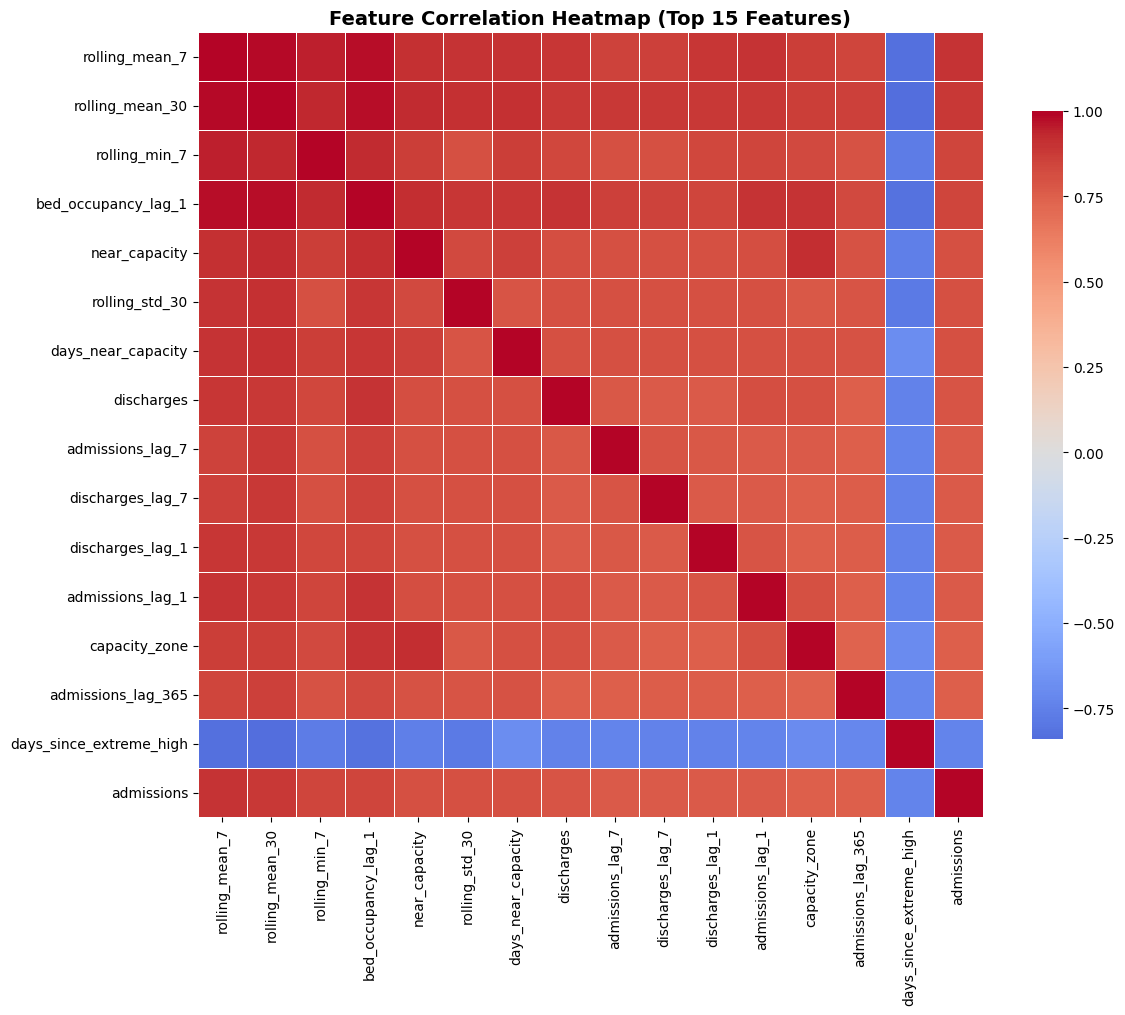


2. Feature importance (top 20 features)...


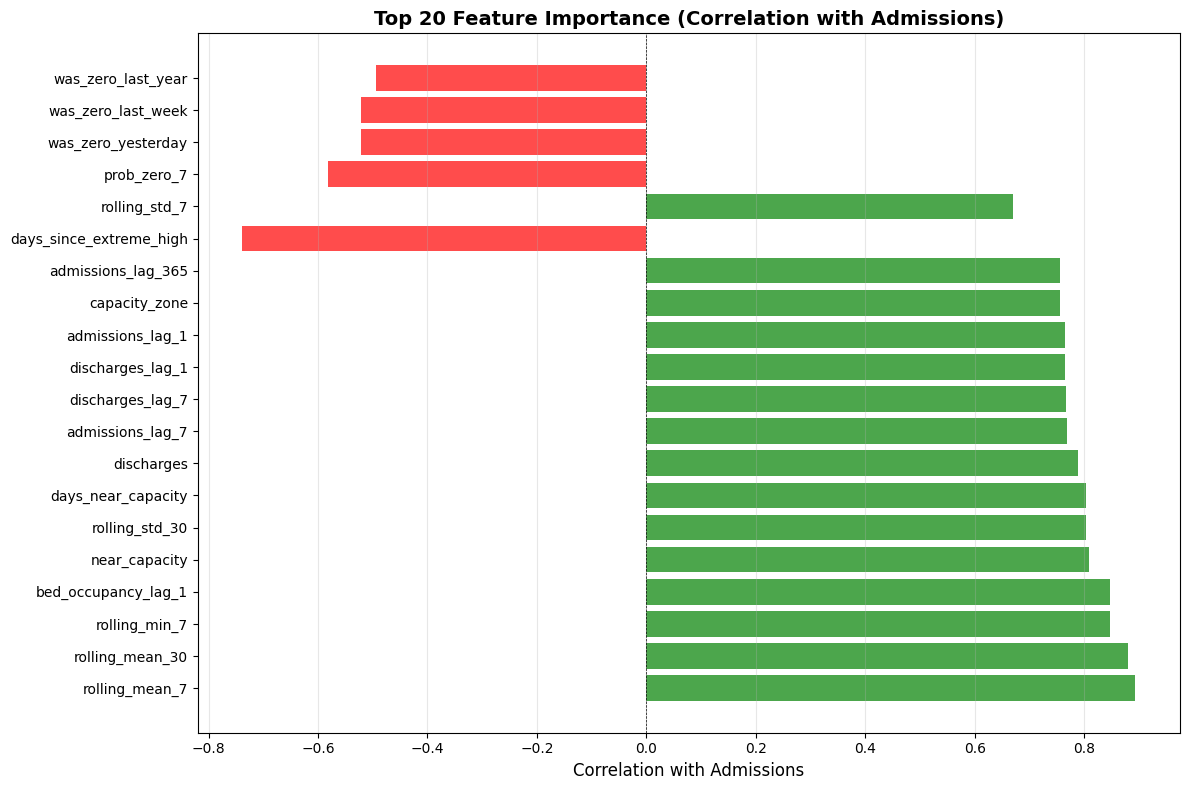


3. Temporal feature distributions...


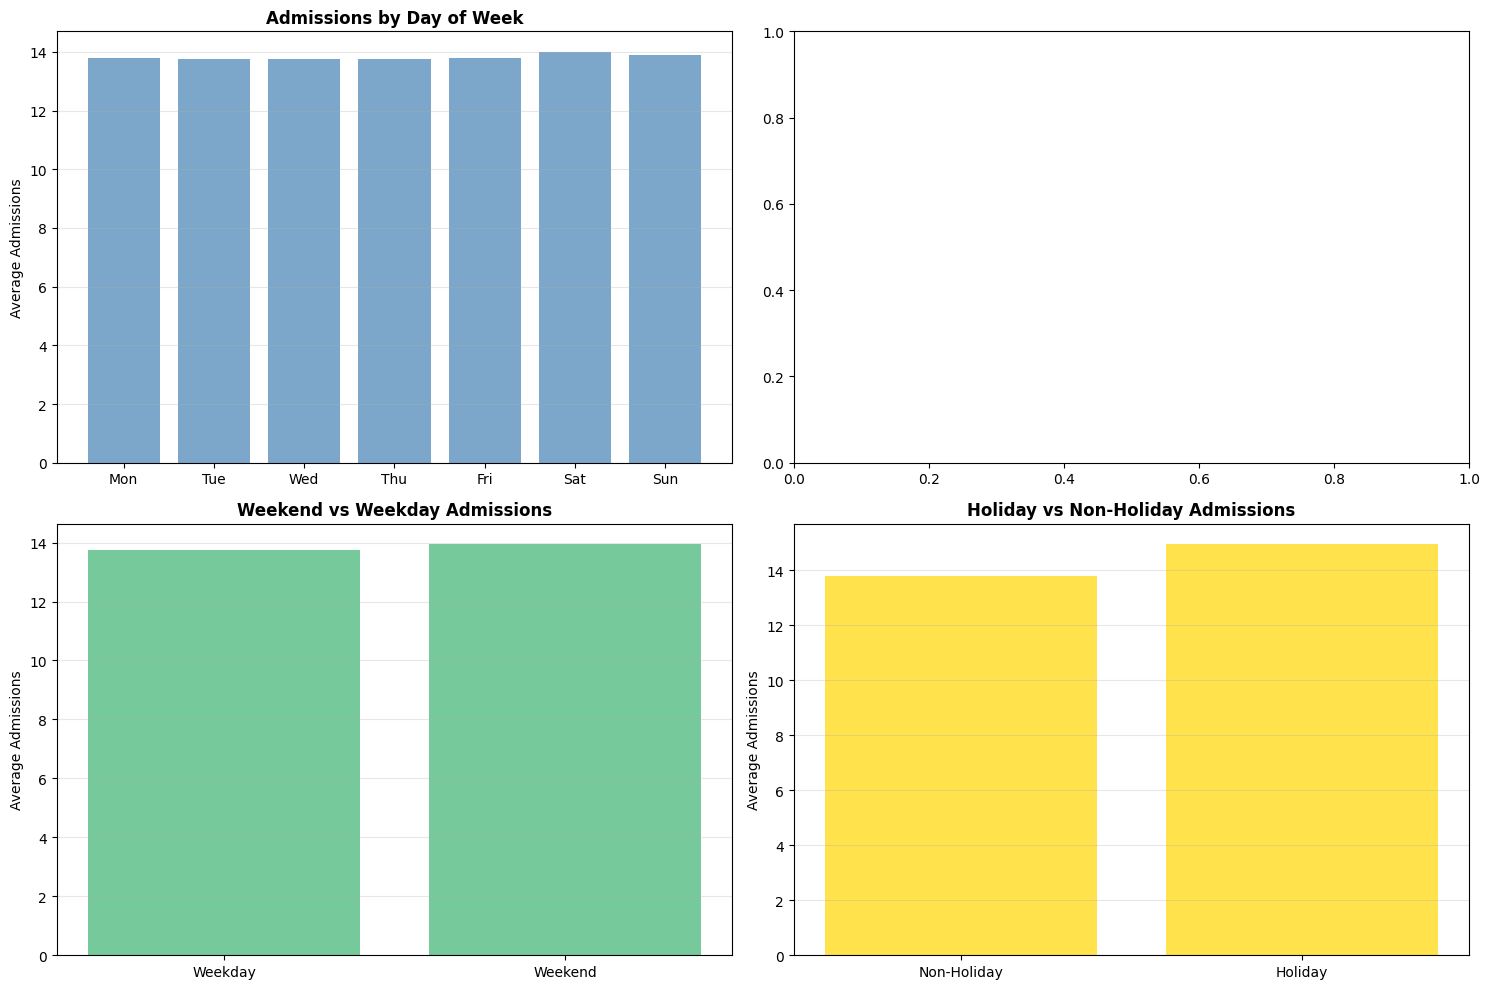

✓ Feature visualizations complete


In [13]:
# Optional: Visualize feature distributions and relationships
# This helps understand the features and identify potential issues
import matplotlib.pyplot as plt
import seaborn as sns

if len(features_df_clean) > 0 and 'admissions' in features_df_clean.columns:
    print("Creating feature visualizations...")

    # Calculate feature importance if not already calculated
    if 'feature_importance' not in locals():
        feature_importance = []
        for col in feature_cols:
            if col != 'admissions' and col in features_df_clean.columns:
                try:
                    corr = features_df_clean[col].corr(features_df_clean['admissions'])
                    if not np.isnan(corr):
                        feature_importance.append((col, abs(corr), corr))
                except:
                    pass
        feature_importance.sort(key=lambda x: x[1], reverse=True)

    # 1. Feature correlation heatmap (top features only)
    print("\n1. Feature correlation heatmap (top 15 features by importance)...")
    if len(feature_importance) > 0:
        top_features = [feat[0] for feat in feature_importance[:15]] + ['admissions']
        top_features = [f for f in top_features if f in features_df_clean.columns]

        if len(top_features) > 1:
            plt.figure(figsize=(12, 10))
            corr_matrix = features_df_clean[top_features].corr()
            sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0,
                       square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
            plt.title('Feature Correlation Heatmap (Top 15 Features)', fontsize=14, fontweight='bold')
            plt.tight_layout()
            plt.show()

    # 2. Feature importance bar chart
    print("\n2. Feature importance (top 20 features)...")
    if len(feature_importance) > 0:
        top_20 = feature_importance[:20]
        features_names = [feat[0] for feat in top_20]
        correlations = [feat[2] for feat in top_20]  # Use signed correlation

        plt.figure(figsize=(12, 8))
        colors = ['green' if c > 0 else 'red' for c in correlations]
        plt.barh(range(len(features_names)), correlations, color=colors, alpha=0.7)
        plt.yticks(range(len(features_names)), features_names)
        plt.xlabel('Correlation with Admissions', fontsize=12)
        plt.title('Top 20 Feature Importance (Correlation with Admissions)', fontsize=14, fontweight='bold')
        plt.axvline(x=0, color='black', linestyle='--', linewidth=0.5)
        plt.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()

    # 3. Temporal feature distributions
    print("\n3. Temporal feature distributions...")
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Day of week pattern
    if 'day_of_week' in features_df_clean.columns:
        dow_avg = features_df_clean.groupby('day_of_week')['admissions'].mean()
        axes[0, 0].bar(range(7), dow_avg.values, color='steelblue', alpha=0.7)
        axes[0, 0].set_xticks(range(7))
        axes[0, 0].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
        axes[0, 0].set_ylabel('Average Admissions', fontsize=10)
        axes[0, 0].set_title('Admissions by Day of Week', fontsize=12, fontweight='bold')
        axes[0, 0].grid(axis='y', alpha=0.3)

    # Month pattern
    if 'month' in features_df_clean.columns:
        month_avg = features_df_clean.groupby('month')['admissions'].mean()
        axes[0, 1].bar(range(1, 13), month_avg.values, color='coral', alpha=0.7)
        axes[0, 1].set_xticks(range(1, 13))
        axes[0, 1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
        axes[0, 1].set_ylabel('Average Admissions', fontsize=10)
        axes[0, 1].set_title('Admissions by Month', fontsize=12, fontweight='bold')
        axes[0, 1].grid(axis='y', alpha=0.3)

    # Weekend vs Weekday
    if 'is_weekend' in features_df_clean.columns:
        weekend_avg = features_df_clean.groupby('is_weekend')['admissions'].mean()
        axes[1, 0].bar(['Weekday', 'Weekend'], weekend_avg.values, color='mediumseagreen', alpha=0.7)
        axes[1, 0].set_ylabel('Average Admissions', fontsize=10)
        axes[1, 0].set_title('Weekend vs Weekday Admissions', fontsize=12, fontweight='bold')
        axes[1, 0].grid(axis='y', alpha=0.3)

    # Holiday effect
    if 'is_holiday' in features_df_clean.columns:
        holiday_avg = features_df_clean.groupby('is_holiday')['admissions'].mean()
        axes[1, 1].bar(['Non-Holiday', 'Holiday'], holiday_avg.values, color='gold', alpha=0.7)
        axes[1, 1].set_ylabel('Average Admissions', fontsize=10)
        axes[1, 1].set_title('Holiday vs Non-Holiday Admissions', fontsize=12, fontweight='bold')
        axes[1, 1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("✓ Feature visualizations complete")
else:
    print("⚠️  Cannot create visualizations - data not available")


## Summary

This notebook:
- ✅ Created temporal features (quarter, day of year, is_weekend, holidays) - **UPDATED**: Removed weak day-of-week/monthly features
- ✅ Added cyclical encoding (sin/cos) for quarter and day of year - **UPDATED**: Removed day-of-week/monthly cyclical
- ✅ Added holiday indicators and interaction features (holiday × weekend)
- ✅ Generated lag features (1, 7, 365 days) - **UPDATED**: Simplified, removed redundant lags (2, 3, 14, 30)
- ✅ Created rolling statistics (mean, median, std for 7, 30, 365-day windows)
- ✅ Added change features (day-over-day, week-over-week)
- ✅ Added time-based features (days since holiday) - **UPDATED**: Removed data leakage features
- ✅ Added interaction features (weekend × quarter) - **UPDATED**: Removed weak interactions
- ✅ Added KPI features with capacity constraints - **UPDATED**: Use lagged capacity to avoid data leakage
- ✅ **NEW:** Zero-inflation features - Explicitly model zero patterns and extreme values (handles zero-inflated, right-skewed distribution)
- ✅ **FIXED:** Removed data leakage features (target encoding, ratio features with current admissions, days_until_next_holiday)
- ✅ **FIXED:** Removed redundant features (weak harmonics, redundant time-based features)
- ✅ Feature validation (constant features, multicollinearity checks)
- ✅ Feature importance analysis
- ✅ Feature visualizations
- ✅ Advanced features (percentiles, volatility, Fourier harmonics for annual, trends) - **UPDATED**: Removed EMA (redundant with rolling mean) and acceleration/momentum (redundant/noisy)
- ✅ Cleaned and saved feature-engineered dataset
- ✅ Created model-specific feature sets (ARIMAX, LSTM, VAR)

**Key Features:**
- **Cyclical encoding (sin/cos)**: Better captures cyclical patterns for ML models
- **Year-over-year lag (365 days)**: Captures annual seasonality patterns
- **Change features**: Captures momentum and short-term trends
- **Rolling medians**: More robust than means for skewed distributions
- **Time-based features**: Days since/until holidays, weekends, month boundaries
- **Interaction features**: Combined effects (e.g., Monday in January vs Monday in July)
- **Capacity constraints**: Hospital capacity features that affect admissions
- **Feature validation**: Automatic detection of constant and highly correlated features
- **Feature importance**: Ranking of features by correlation with target

**Advanced Features (UPDATED):**
- **Percentile-based features**: Robust to outliers (25th, 75th, 90th percentiles)
- **Volatility features**: Coefficient of variation and rolling range to measure variability
- **Calendar effects**: First/last week of month, day/week of quarter
- **Fourier harmonics**: Additional frequency components for complex seasonality (annual harmonics)
- **Autocorrelation features**: Rolling autocorrelation approximations
- **Trend features**: Linear trend components and rolling slopes
- **REMOVED**: EMA (redundant with rolling mean), Acceleration/Momentum (redundant/noisy), Target encoding (data leakage), Ratio features (data leakage)

**Feature Statistics:**
- Total features created: ~100-120 (varies based on KPI availability and advanced features)
- Model-specific sets: ARIMAX (7), LSTM (19), VAR (7)
- All features validated for quality and importance

**Next Steps:** Proceed to `04a_baseline_models.ipynb` and subsequent model notebooks to train forecasting models.


## Summary

This notebook:
- ✅ Created temporal features (day of week, month, quarter, day of year, week of month, etc.)
- ✅ Added cyclical encoding (sin/cos) for day of week, month, and day of year (better for ML models)
- ✅ Added holiday indicators and interaction features (holiday × weekend)
- ✅ Generated lag features (1, 2, 3, 7, 14, 30, 365 days - year-over-year)
- ✅ Created rolling statistics (mean, median, std, min, max for 7, 30, 365-day windows)
- ✅ Added change features (day-over-day, week-over-week, month-over-month)
- ✅ Added KPI features if available
- ✅ Cleaned and saved feature-engineered dataset

**New Features Added:**
- **Cyclical encoding (sin/cos)**: Better captures cyclical patterns for ML models
- **Year-over-year lag (365 days)**: Captures annual seasonality patterns
- **Change features**: Captures momentum and short-term trends
- **Rolling medians**: More robust than means for skewed distributions
- **Quarter start/end flags**: Captures quarterly patterns
- **Holiday-weekend interactions**: Captures special holiday weekends

**Next Steps:** Proceed to `04_model_development.ipynb` to train forecasting models.
